# main lorenz class

In [2]:
import numpy as np
import pandas as pd
from scipy.signal import hilbert
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize, differential_evolution
from scipy.signal import find_peaks, argrelextrema
import matplotlib.pyplot as plt

class Lorentz:
    def __init__(self, s = 10, r = 28, b = 8/3):
        self.s = s
        self.r = r
        self.b = b

    # Differential equations of a Lorenz System
    def X(self, x, y, s):
        return s * (y - x)

    def Y(self, x, y, z, r):
        return (-x) * z + r * x - y

    def Z(self, x, y, z, b):
        return x * y - b * z

    # RK4 for the differential equations
    def RK4(self, x, y, z, s, r, b, dt):
        k_1 = self.X(x, y, s)
        l_1 = self.Y(x, y, z, r)
        m_1 = self.Z(x, y, z, b)

        k_2 = self.X((x + k_1 * dt * 0.5), (y + l_1 * dt * 0.5), s)
        l_2 = self.Y((x + k_1 * dt * 0.5), (y + l_1 * dt * 0.5), (z + m_1 * dt * 0.5), r)
        m_2 = self.Z((x + k_1 * dt * 0.5), (y + l_1 * dt * 0.5), (z + m_1 * dt * 0.5), b)

        k_3 = self.X((x + k_2 * dt * 0.5), (y + l_2 * dt * 0.5), s)
        l_3 = self.Y((x + k_2 * dt * 0.5), (y + l_2 * dt * 0.5), (z + m_2 * dt * 0.5), r)
        m_3 = self.Z((x + k_2 * dt * 0.5), (y + l_2 * dt * 0.5), (z + m_2 * dt * 0.5), b)

        k_4 = self.X((x + k_3 * dt), (y + l_3 * dt), s)
        l_4 = self.Y((x + k_3 * dt), (y + l_3 * dt), (z + m_3 * dt), r)
        m_4 = self.Z((x + k_3 * dt), (y + l_3 * dt), (z + m_3 * dt), b)

        x += (k_1 + 2 * k_2 + 2 * k_3 + k_4) * dt * (1/6)
        y += (l_1 + 2 * l_2 + 2 * l_3 + l_4) * dt * (1/6)
        z += (m_1 + 2 * m_2 + 2 * m_3 + m_4) * dt * (1/6)

        return (x, y, z)

    def generate(self, dt, steps):
        # Initial values and Parameters
        x_0, y_0, z_0 = 1, 1, 1

        # RK4 iteration
        x_list = [x_0]
        y_list = [y_0]
        z_list = [z_0]

        i = 0

        while i < steps:
            x = x_list[i]
            y = y_list[i]
            z = z_list[i]

            position = self.RK4(x, y, z, self.s, self.r, self.b, dt)

            x_list.append(position[0])
            y_list.append(position[1])
            z_list.append(position[2])

            i += 1

        x_array = np.array(x_list)
        y_array = np.array(y_list)
        z_array = np.array(z_list)

        return x_array, y_array, z_array
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

def denormalize(arr, min, max):
    return arr * (max - min) + min
x, _, _ = Lorentz().generate(0.1, 100000)

x_max = x.max()
x_min = x.min()
x = normalize(x)

# glueing series together

In [3]:
def extract_simple_features(window, sfreq):
    """Extract features from a window of data"""
    features = {}

    # Basic statistics
    features['std'] = np.std(window)
    features['rms'] = np.sqrt(np.mean(window**2))
    features['peak_to_peak'] = np.ptp(window)

    # Complexity
    features['line_length'] = np.sum(np.abs(np.diff(window)))
    features['zero_crossing'] = np.sum(np.diff(np.sign(window)) != 0) / len(window)

    # Hjorth parameters
    var_window = np.var(window)
    if var_window > 0:
        diff1 = np.diff(window)
        diff2 = np.diff(diff1)
        features['hjorth_mobility'] = np.std(diff1) / np.std(window)
        features['hjorth_complexity'] = (np.std(diff2) / np.std(diff1)) / features['hjorth_mobility'] if features['hjorth_mobility'] > 0 else 0
    else:
        features['hjorth_mobility'] = 0
        features['hjorth_complexity'] = 0

    # Envelope features
    analytic = hilbert(window)
    envelope = np.abs(analytic)
    features['envelope_std'] = np.std(envelope)
    features['envelope_max'] = np.max(envelope)
    features['envelope_mean'] = np.mean(envelope)

    return features

# Generate data with parameter changes
print("Generating Lorenz data with parameter changes...")

# Parameters
sfreq = 100  # sampling frequency for windows (we'll use 100 Hz as base)
dt = 0.01  # 100 Hz
points_per_segment = 192000
skip_points = 1000

# Generate data segments with alternating r values
segments = []
change_times = []
current_time = 0
labels = []

for i in range(5):  # Generate 5 segments
    r_value = 28.0 if i % 2 == 0 else 29.4

    # Generate data
    lorenz = Lorentz(r=r_value)
    x, _, _ = lorenz.generate(dt, points_per_segment + skip_points)

    # Skip first 1000 points and normalize
    x = x[skip_points:]
    x_norm = normalize(x)

    segments.append(x_norm)

    # Record change times
    if i > 0:
        change_times.append(current_time)
        labels.append(current_time)

    current_time += len(x_norm) / sfreq

# Combine all segments
data = np.concatenate(segments)
total_duration = len(data) / sfreq
time = np.arange(len(data)) / sfreq

print(f"Total data points: {len(data)}")
print(f"Total duration: {total_duration:.2f} seconds")
print(f"Change times (seconds): {change_times}")

Generating Lorenz data with parameter changes...
Total data points: 960005
Total duration: 9600.05 seconds
Change times (seconds): [1920.01, 3840.02, 5760.03, 7680.04]


# windows

In [ ]:
window_size_sec = 0.5
step_size_sec = 0.01
window_size = int(window_size_sec * sfreq)
step_size = int(step_size_sec * sfreq)

windows = []
window_centers = []

for start in range(0, len(data) - window_size, step_size):
    window = data[start:start + window_size]
    center_time = start / sfreq + window_size_sec/2
    windows.append(window)
    window_centers.append(center_time)

windows = np.array(windows)
window_centers = np.array(window_centers)
print(f"Total windows: {len(windows)}")

# Extract features
print("Extracting features...")
feature_list = []
for i, w in enumerate(windows):
    feature_list.append(extract_simple_features(w, sfreq))
    if (i+1) % 2000 == 0:
        print(f"  {i+1}/{len(windows)}", end='\r')

features_df = pd.DataFrame(feature_list)
feature_names = features_df.columns.tolist()
print(f"\nExtracted {len(feature_names)} features: {feature_names}")

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(features_df)

# differential evolution

In [ ]:
def create_indicator_function(X, window_centers, feature_names, window_sizes):
    """Create indicator function I(t) as linear combination of features"""

    def I(t, params, feature_data, centers, sizes):
        """Indicator function value at time t"""
        n_features = feature_data.shape[1]
        n_scales = len(sizes)
        total_params_per_scale = n_features + 1  # features + bias

        result = 0

        for scale_idx, scale in enumerate(sizes):
            # Get parameters for this scale
            start_idx = scale_idx * total_params_per_scale
            scale_params = params[start_idx:start_idx + total_params_per_scale]
            bias = scale_params[0]
            weights = scale_params[1:]

            # Find windows that cover time t within this scale
            scale_centers = centers
            # Use a Gaussian weighting based on distance to t
            distances = np.abs(scale_centers - t)
            sigma = scale / 6  # scale in time units

            # Weight features by temporal proximity
            weights_temporal = np.exp(-0.5 * (distances / sigma)**2)
            weights_temporal /= weights_temporal.sum()

            # Weighted average of features at this scale
            weighted_features = np.average(feature_data, axis=0, weights=weights_temporal)
            scale_contribution = bias + np.dot(weights, weighted_features)
            result += scale_contribution

        return result

    return I

# Define loss function for optimization
def create_loss_function(window_centers, X, feature_names, change_times, window_sizes):
    """Create loss function that penalizes misalignment of local minima with change times"""

    def loss(params):
        # Create indicator function
        n_features = len(feature_names)
        n_scales = len(window_sizes)

        # Evaluate indicator at all window centers
        I_values = np.zeros(len(window_centers))
        for i, t in enumerate(window_centers):
            I_val = 0
            for scale_idx, scale in enumerate(window_sizes):
                start_idx = scale_idx * (n_features + 1)
                scale_params = params[start_idx:start_idx + (n_features + 1)]
                bias = scale_params[0]
                weights = scale_params[1:]

                distances = np.abs(window_centers - t)
                sigma = scale / 6
                weights_temporal = np.exp(-0.5 * (distances / sigma)**2)
                weights_temporal /= weights_temporal.sum()

                weighted_features = np.average(X, axis=0, weights=weights_temporal)
                scale_contribution = bias + np.dot(weights, weighted_features)
                I_val += scale_contribution

            I_values[i] = I_val

        # Find local minima (neighborhood of 1000 points in both directions)
        neighborhood = 1000
        local_minima_indices = []
        for i in range(neighborhood, len(I_values) - neighborhood):
            left_slice = I_values[i-neighborhood:i]
            right_slice = I_values[i+1:i+neighborhood+1]
            if I_values[i] < np.min(left_slice) and I_values[i] < np.min(right_slice):
                local_minima_indices.append(i)

        local_minima_times = window_centers[local_minima_indices]

        # Penalize: for each change time, find closest local minimum
        if len(local_minima_times) == 0:
            return 1e6

        total_distance = 0
        min_distance_penalty = 0

        for change_time in change_times:
            distances = np.abs(local_minima_times - change_time)
            closest_idx = np.argmin(distances)
            closest_distance = distances[closest_idx]

            # Penalize if closest minimum is more than 50 timestamps (0.5 seconds) away
            if closest_distance > 50 / sfreq:
                min_distance_penalty += (closest_distance - 50/sfreq) ** 2

            total_distance += closest_distance

        # Penalize too many local minima
        excess_minima = max(0, len(local_minima_times) - len(change_times) - 2)  # Allow 2 extra
        excess_minima_penalty = excess_minima * 100

        # Also penalize if there are fewer minima than change times
        missing_minima = max(0, len(change_times) - len(local_minima_times))
        missing_minima_penalty = missing_minima * 1000

        return total_distance + min_distance_penalty + excess_minima_penalty + missing_minima_penalty

    return loss

# Optimization
print("\nOptimizing parameters...")
window_sizes = [80, 240, 480]
n_features = len(feature_names)
n_params = len(window_sizes) * (n_features + 1)

# Initial guess
initial_params = np.random.randn(n_params) * 0.1

# Create loss function
loss_fn = create_loss_function(window_centers, X, feature_names, change_times, window_sizes)

# Use differential evolution for global optimization
print("Running differential evolution...")
bounds = [(-5, 5)] * n_params

result = differential_evolution(
    loss_fn,
    bounds,
    maxiter=100,
    popsize=30,
    mutation=(0.5, 1.5),
    recombination=0.7,
    seed=42,
    disp=True
)

In [ ]:
optimized_params = result.x
print(f"Optimization completed. Final loss: {result.fun}")

# Display parameters
print("\n=== Optimized Parameters ===")
for scale_idx, scale in enumerate(window_sizes):
    start_idx = scale_idx * (n_features + 1)
    scale_params = optimized_params[start_idx:start_idx + (n_features + 1)]
    print(f"\nWindow size {scale}:")
    print(f"  Bias: {scale_params[0]:.4f}")
    for feat_idx, feat_name in enumerate(feature_names):
        print(f"  {feat_name}: {scale_params[feat_idx + 1]:.4f}")

# Compute final indicator values
print("\nComputing final indicator function...")
I_values = np.zeros(len(window_centers))
for i, t in enumerate(window_centers):
    I_val = 0
    for scale_idx, scale in enumerate(window_sizes):
        start_idx = scale_idx * (n_features + 1)
        scale_params = optimized_params[start_idx:start_idx + (n_features + 1)]
        bias = scale_params[0]
        weights = scale_params[1:]

        distances = np.abs(window_centers - t)
        sigma = scale / 6
        weights_temporal = np.exp(-0.5 * (distances / sigma)**2)
        weights_temporal /= weights_temporal.sum()

        weighted_features = np.average(X, axis=0, weights=weights_temporal)
        scale_contribution = bias + np.dot(weights, weighted_features)
        I_val += scale_contribution

    I_values[i] = I_val

# results

In [ ]:
neighborhood = 1000
local_minima_indices = []
for i in range(neighborhood, len(I_values) - neighborhood):
    left_slice = I_values[i-neighborhood:i]
    right_slice = I_values[i+1:i+neighborhood+1]
    if I_values[i] < np.min(left_slice) and I_values[i] < np.min(right_slice):
        local_minima_indices.append(i)

detected_changes = window_centers[local_minima_indices]
print(f"\nDetected {len(detected_changes)} local minima")
print(f"True change times: {change_times}")
print(f"Detected change times: {detected_changes}")

# plot

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(15, 20))

# Plot 1: Beginning of data (first 100000 points)
plot_points = 100000
plot_time_start = 0
plot_time_end = plot_points / sfreq

# Find windows in this range
mask = (window_centers >= plot_time_start) & (window_centers <= plot_time_end)
plot_I = I_values[mask]
plot_times = window_centers[mask]

# Find local minima in this range
minima_in_range = detected_changes[(detected_changes >= plot_time_start) & (detected_changes <= plot_time_end)]

axes[0].plot(plot_times, plot_I, 'b-', linewidth=0.5, alpha=0.7)
axes[0].set_title(f'Indicator Function - First {plot_points} Points (Window size={window_sizes})')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('I(t)')

# Add vertical lines at local minima
for min_time in minima_in_range:
    axes[0].axvline(x=min_time, color='red', linestyle='--', alpha=0.5, linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Plot 2-5: Around each change time
for idx, change_time in enumerate(change_times[:4]):  # Show 4 changes
    ax = axes[idx + 1]

    # Plot 50000 points (500 seconds) around change
    window_around = 250  # seconds on each side
    plot_time_start = max(0, change_time - window_around)
    plot_time_end = min(total_duration, change_time + window_around)

    mask = (window_centers >= plot_time_start) & (window_centers <= plot_time_end)
    plot_I = I_values[mask]
    plot_times = window_centers[mask]

    ax.plot(plot_times, plot_I, 'b-', linewidth=0.5, alpha=0.7)
    ax.axvline(x=change_time, color='green', linestyle='-', linewidth=2, label='True change')
    ax.set_title(f'Around Change {idx+1} at t={change_time:.1f}s')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('I(t)')

    # Find detected minima in this range
    minima_in_range = detected_changes[(detected_changes >= plot_time_start) & (detected_changes <= plot_time_end)]
    for min_time in minima_in_range:
        ax.axvline(x=min_time, color='red', linestyle='--', alpha=0.5, linewidth=0.5)

    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lorenz_change_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n=== Summary ===")
for i, (true_time, detected_time) in enumerate(zip(change_times, detected_changes[:len(change_times)])):
    error = abs(true_time - detected_time)
    print(f"Change {i+1}: True={true_time:.2f}s, Detected={detected_time:.2f}s, Error={error:.2f}s ({error*sfreq:.0f} samples)")

if len(detected_changes) > len(change_times):
    print(f"\nExtra detected minima: {len(detected_changes) - len(change_times)}")
    for i in range(len(change_times), len(detected_changes)):
        print(f"  Extra minimum at t={detected_changes[i]:.2f}s")

# whole pipeline

## generating

In [15]:
import numpy as np
import pandas as pd
from scipy.signal import hilbert
from sklearn.preprocessing import StandardScaler
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt

class Lorentz:
    def __init__(self, s=10, r=28, b=8/3):
        self.s, self.r, self.b = s, r, b

    def X(self, x, y, s): return s * (y - x)
    def Y(self, x, y, z, r): return -x*z + r*x - y
    def Z(self, x, y, z, b): return x*y - b*z

    def RK4(self, x, y, z, s, r, b, dt):
        k1 = self.X(x, y, s)
        l1 = self.Y(x, y, z, r)
        m1 = self.Z(x, y, z, b)

        k2 = self.X(x + k1*dt/2, y + l1*dt/2, s)
        l2 = self.Y(x + k1*dt/2, y + l1*dt/2, z + m1*dt/2, r)
        m2 = self.Z(x + k1*dt/2, y + l1*dt/2, z + m1*dt/2, b)

        k3 = self.X(x + k2*dt/2, y + l2*dt/2, s)
        l3 = self.Y(x + k2*dt/2, y + l2*dt/2, z + m2*dt/2, r)
        m3 = self.Z(x + k2*dt/2, y + l2*dt/2, z + m2*dt/2, b)

        k4 = self.X(x + k3*dt, y + l3*dt, s)
        l4 = self.Y(x + k3*dt, y + l3*dt, z + m3*dt, r)
        m4 = self.Z(x + k3*dt, y + l3*dt, z + m3*dt, b)

        x += (k1 + 2*k2 + 2*k3 + k4) * dt / 6
        y += (l1 + 2*l2 + 2*l3 + l4) * dt / 6
        z += (m1 + 2*m2 + 2*m3 + m4) * dt / 6
        return x, y, z

    def generate(self, dt, steps):
        x, y, z = 1, 1, 1
        x_list = [x]
        for _ in range(steps):
            x, y, z = self.RK4(x, y, z, self.s, self.r, self.b, dt)
            x_list.append(x)
        return np.array(x_list), None, None

# Generate data with alternating r values
print("Generating data...")
dt = 0.01
points_per_segment = 192000
skip = 1000
segments = []
change_indices = []
current_idx = 0

for i in range(5):
    r = 28.0 if i % 2 == 0 else 29.4
    lorenz = Lorentz(r=r)
    x, _, _ = lorenz.generate(dt, points_per_segment + skip)
    x = x[skip:]
    x_norm = (x - x.min()) / (x.max() - x.min())
    segments.append(x_norm)
    if i > 0:
        change_indices.append(current_idx)
    current_idx += len(x_norm)

data = np.concatenate(segments)
print(f"Total points: {len(data)}, Changes at: {change_indices}")

Generating data...
Total points: 960005, Changes at: [192001, 384002, 576003, 768004]


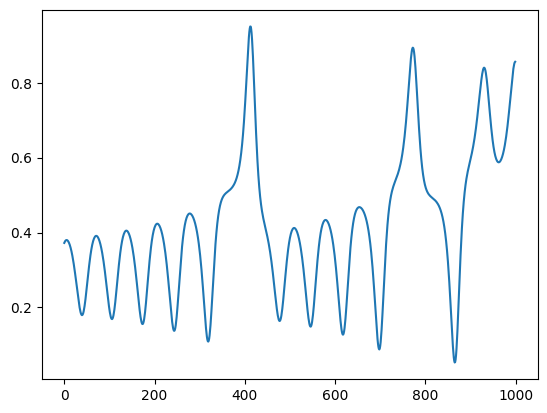

In [16]:
plt.plot(data[:1000])

## windows + features

In [17]:
# Extract features using window of 51 points (25 before, 25 after)
print("Extracting features...")
half_window = 25
window_size = 2 * half_window + 1  # 51
features = []
valid_indices = []

for i in range(half_window, len(data) - half_window):
    window = data[i - half_window:i + half_window + 1]

    f = {}
    f['std'] = np.std(window)
    f['rms'] = np.sqrt(np.mean(window**2))
    f['peak_to_peak'] = np.ptp(window)
    f['line_length'] = np.sum(np.abs(np.diff(window)))
    f['zero_crossing'] = np.sum(np.diff(np.sign(window)) != 0) / len(window)

    var = np.var(window)
    if var > 0:
        diff1 = np.diff(window)
        diff2 = np.diff(diff1)
        f['hjorth_mobility'] = np.std(diff1) / np.std(window)
        mobility = f['hjorth_mobility']
        f['hjorth_complexity'] = np.std(diff2) / np.std(diff1) / mobility if mobility > 0 else 0
    else:
        f['hjorth_mobility'] = 0
        f['hjorth_complexity'] = 0

    analytic = hilbert(window)
    envelope = np.abs(analytic)
    f['envelope_std'] = np.std(envelope)
    f['envelope_max'] = np.max(envelope)
    f['envelope_mean'] = np.mean(envelope)

    features.append(f)
    valid_indices.append(i)

features_df = pd.DataFrame(features)
feature_names = features_df.columns.tolist()
valid_indices = np.array(valid_indices)
print(f"Extracted {len(feature_names)} features for {len(features)} points")
print(f"Features: {feature_names}")

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(features_df)

Extracting features...
Extracted 10 features for 959955 points
Features: ['std', 'rms', 'peak_to_peak', 'line_length', 'zero_crossing', 'hjorth_mobility', 'hjorth_complexity', 'envelope_std', 'envelope_max', 'envelope_mean']


## differential evolution

In [ ]:
# Define indicator function: I(t) = a0 + a1*feat1 + a2*feat2 + ... + an*featn
# I(t) is simply a linear combination of features at each point
def compute_indicator(params, X_data):
    """I(t) = bias + sum(weights * features)"""
    bias = params[0]
    weights = params[1:]
    return bias + X_data @ weights

# Loss function
def loss_function(params):
    I = compute_indicator(params, X)

    # Find local minima (neighborhood of 1000 points in both directions)
    neighborhood = 1000
    minima_indices = []
    for i in range(neighborhood, len(I) - neighborhood):
        if I[i] < np.min(I[i-neighborhood:i]) and I[i] < np.min(I[i+1:i+neighborhood+1]):
            minima_indices.append(i)

    if len(minima_indices) == 0:
        return 1e6

    minima_positions = valid_indices[minima_indices]

    # For each change, find closest minimum
    total_loss = 0
    for change_idx in change_indices:
        distances = np.abs(minima_positions - change_idx)
        closest_dist = distances.min()
        # Penalize if further than 50 points
        if closest_dist > 50:
            total_loss += (closest_dist - 50) ** 2
        total_loss += closest_dist

    # Penalize extra minima
    extra = max(0, len(minima_indices) - len(change_indices) - 2)
    total_loss += extra * 1000

    # Penalize missing minima
    missing = max(0, len(change_indices) - len(minima_indices))
    total_loss += missing * 10000

    return total_loss

# Optimize
print("\nOptimizing parameters...")
n_params = len(feature_names) + 1  # bias + one weight per feature
bounds = [(-5, 5)] * n_params

result = differential_evolution(
    loss_function,
    bounds,
    maxiter=200,
    popsize=30,
    seed=42,
    disp=True
)

Optimizing parameters...\\
differential_evolution step 1: f(x)= 419268.0\\


differential_evolution step 2: f(x)= 419146.0\\

differential_evolution step 3: f(x)= 419122.0\\

differential_evolution step 4: f(x)= 419122.0\\

differential_evolution step 5: f(x)= 419122.0\\

differential_evolution step 6: f(x)= 419122.0\\

differential_evolution step 7: f(x)= 414340.0\\

differential_evolution step 8: f(x)= 414340.0\\

differential_evolution step 9: f(x)= 414340.0\\

differential_evolution step 10: f(x)= 414340.0\\

differential_evolution step 11: f(x)= 414340.0\\

differential_evolution step 12: f(x)= 411174.0\\

differential_evolution step 13: f(x)= 411174.0\\

differential_evolution step 14: f(x)= 411174.0\\

differential_evolution step 15: f(x)= 411174.0\\

## results

In [ ]:
print("\n=== Optimized Parameters ===")
print(f"Bias: {result.x[0]:.4f}")
for i, name in enumerate(feature_names):
    print(f"{name}: {result.x[i+1]:.4f}")

# Compute final indicator
I_final = compute_indicator(result.x, X)

## minima

In [ ]:
# Find minima in final indicator
neighborhood = 1000
final_minima_indices = []
for i in range(neighborhood, len(I_final) - neighborhood):
    if I_final[i] < np.min(I_final[i-neighborhood:i]) and I_final[i] < np.min(I_final[i+1:i+neighborhood+1]):
        final_minima_indices.append(i)

detected_changes = valid_indices[final_minima_indices]
print(f"\nTrue changes at:    {change_indices}")
print(f"Detected changes at: {detected_changes}")

# Calculate errors
print("\nDetection accuracy:")
for i, (true, det) in enumerate(zip(change_indices, detected_changes[:len(change_indices)])):
    error = abs(true - det)
    print(f"Change {i+1}: True={true}, Detected={det}, Error={error} points")

## plot

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(15, 20))

# Plot 1: First 100,000 points
mask = valid_indices < 100000
axes[0].plot(valid_indices[mask], I_final[mask], 'b-', linewidth=0.5)
axes[0].set_title('Indicator Function - First 100,000 points')
for dc in detected_changes:
    if dc < 100000:
        axes[0].axvline(dc, color='red', linestyle='--', alpha=0.5, label='Detected' if dc == detected_changes[0] else '')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plots 2-5: Around each change
for idx, change in enumerate(change_indices[:4]):
    ax = axes[idx+1]
    window = 50000
    mask = (valid_indices >= change - window) & (valid_indices <= change + window)
    ax.plot(valid_indices[mask], I_final[mask], 'b-', linewidth=0.5)
    ax.axvline(change, color='green', linewidth=2, label='True change')
    for dc in detected_changes:
        if change - window <= dc <= change + window:
            ax.axvline(dc, color='red', linestyle='--', alpha=0.5, label='Detected' if dc == detected_changes[0] else '')
    ax.set_title(f'Change {idx+1} at point {change}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lorenz_detection.png', dpi=150)
plt.show()

# cascade

## generate data code

In [27]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.spatial.distance import pdist, squareform
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

In [19]:
import numpy as np
import pandas as pd
from scipy.signal import hilbert
from sklearn.preprocessing import StandardScaler
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt

class Lorentz:
    def __init__(self, s=10, r=28, b=8/3):
        self.s, self.r, self.b = s, r, b

    def X(self, x, y, s): return s * (y - x)
    def Y(self, x, y, z, r): return -x*z + r*x - y
    def Z(self, x, y, z, b): return x*y - b*z

    def RK4(self, x, y, z, s, r, b, dt):
        k1 = self.X(x, y, s)
        l1 = self.Y(x, y, z, r)
        m1 = self.Z(x, y, z, b)

        k2 = self.X(x + k1*dt/2, y + l1*dt/2, s)
        l2 = self.Y(x + k1*dt/2, y + l1*dt/2, z + m1*dt/2, r)
        m2 = self.Z(x + k1*dt/2, y + l1*dt/2, z + m1*dt/2, b)

        k3 = self.X(x + k2*dt/2, y + l2*dt/2, s)
        l3 = self.Y(x + k2*dt/2, y + l2*dt/2, z + m2*dt/2, r)
        m3 = self.Z(x + k2*dt/2, y + l2*dt/2, z + m2*dt/2, b)

        k4 = self.X(x + k3*dt, y + l3*dt, s)
        l4 = self.Y(x + k3*dt, y + l3*dt, z + m3*dt, r)
        m4 = self.Z(x + k3*dt, y + l3*dt, z + m3*dt, b)

        x += (k1 + 2*k2 + 2*k3 + k4) * dt / 6
        y += (l1 + 2*l2 + 2*l3 + l4) * dt / 6
        z += (m1 + 2*m2 + 2*m3 + m4) * dt / 6
        return x, y, z

    def generate(self, dt, steps):
        x, y, z = 1, 1, 1
        x_list = [x]
        for _ in range(steps):
            x, y, z = self.RK4(x, y, z, self.s, self.r, self.b, dt)
            x_list.append(x)
        return np.array(x_list), None, None

# Generate data with alternating r values
print("Generating data...")
dt = 0.01
points_per_segment = 192000
skip = 1000
segments = []
change_indices = []
current_idx = 0

for i in range(5):
    r = 28.0 if i % 2 == 0 else 29.4
    lorenz = Lorentz(r=r)
    x, _, _ = lorenz.generate(dt, points_per_segment + skip)
    x = x[skip:]
    x_norm = (x - x.min()) / (x.max() - x.min())
    segments.append(x_norm)
    if i > 0:
        change_indices.append(current_idx)
    current_idx += len(x_norm)

data = np.concatenate(segments)
print(f"Total points: {len(data)}, Changes at: {change_indices}")

Generating data...
Total points: 960005, Changes at: [192001, 384002, 576003, 768004]


## features

In [24]:
# CELL 2: Feature extraction functions
def recurrence_features(window):
    n = len(window)
    dist_matrix = squareform(pdist(window.reshape(-1, 1)))
    threshold = np.percentile(dist_matrix, 10)
    rec_matrix = (dist_matrix <= threshold).astype(int)
    np.fill_diagonal(rec_matrix, 0)

    diag_lengths = []
    for k in range(-n+1, n):
        diag = np.diag(rec_matrix, k)
        if len(diag) >= 2:
            count = 0
            for val in diag:
                if val == 1: count += 1
                else:
                    if count >= 2: diag_lengths.append(count)
                    count = 0
            if count >= 2: diag_lengths.append(count)

    features = {}
    features['rec_rate'] = np.sum(rec_matrix) / (n * (n - 1))
    total_diag = sum(diag_lengths)
    features['determinism'] = total_diag / (np.sum(rec_matrix) + 1e-10)
    features['avg_diag'] = np.mean(diag_lengths) if diag_lengths else 0
    features['max_diag'] = max(diag_lengths) if diag_lengths else 0
    if len(diag_lengths) > 1:
        hist, _ = np.histogram(diag_lengths, bins=min(10, len(diag_lengths)))
        hist = hist / (hist.sum() + 1e-10)
        features['diag_entropy'] = -np.sum(hist * np.log(hist + 1e-10))
    else:
        features['diag_entropy'] = 0

    # Vertical lines
    vert_lengths = []
    for j in range(n):
        col = rec_matrix[:, j]
        count = 0
        for val in col:
            if val == 1: count += 1
            else:
                if count >= 2: vert_lengths.append(count)
                count = 0
        if count >= 2: vert_lengths.append(count)

    total_vert = sum(vert_lengths)
    features['laminarity'] = total_vert / (np.sum(rec_matrix) + 1e-10)
    features['trapping_time'] = np.mean(vert_lengths) if vert_lengths else 0

    return features

def nonlinear_features(window):
    n = len(window)
    features = {}

    r = 0.2 * np.std(window)
    if r == 0:
        return {k: 0 for k in ['sample_entropy', 'perm_entropy', 'hurst', 'lyap']}

    def count_matches(data, m):
        templates = np.array([data[i:i+m] for i in range(n-m)])
        count = 0
        for i in range(len(templates)):
            distances = np.max(np.abs(templates - templates[i]), axis=1)
            count += np.sum(distances < r) - 1
        return count

    A = count_matches(window, 2)
    B = count_matches(window, 3)
    features['sample_entropy'] = -np.log((A + 1e-10) / (B + 1e-10))

    perms = []
    for i in range(n-2):
        segment = window[i:i+3]
        perms.append(tuple(np.argsort(segment)))
    unique, counts = np.unique(perms, axis=0, return_counts=True)
    probs = counts / len(perms)
    features['perm_entropy'] = -np.sum(probs * np.log(probs + 1e-10))

    lags = range(2, min(20, n//2))
    tau = []
    for lag in lags:
        chunks = [window[i:i+lag] for i in range(0, n-lag, lag)]
        if len(chunks) < 4: continue
        rs = []
        for chunk in chunks:
            if np.std(chunk) > 0:
                rs.append((np.max(np.cumsum(chunk-np.mean(chunk))) -
                          np.min(np.cumsum(chunk-np.mean(chunk)))) / np.std(chunk))
        if rs: tau.append([np.log(lag), np.log(np.mean(rs))])
    features['hurst'] = np.polyfit(np.array(tau)[:,0], np.array(tau)[:,1], 1)[0] if len(tau) > 1 else 0.5

    emb_dim = 3
    embedded = np.array([window[i:i+emb_dim] for i in range(n-emb_dim)])
    d1 = []
    for i in range(len(embedded)-10):
        dists = np.sqrt(np.sum((embedded - embedded[i])**2, axis=1))
        dists[i] = np.inf
        nearest = np.argmin(dists)
        if i+10 < len(embedded) and nearest+10 < len(embedded):
            d0 = np.sqrt(np.sum((embedded[i]-embedded[nearest])**2))
            if d0 > 0:
                d1.append(np.log(np.sqrt(np.sum((embedded[i+10]-embedded[nearest+10])**2))/d0))
    features['lyap'] = np.mean(d1)/10 if d1 else 0

    return features

def extract_features(window):
    features = {}
    features.update(nonlinear_features(window))
    features.update(recurrence_features(window))
    return list(features.values())

## simpler features

In [34]:
# CELL 2: Feature extraction functions (simplified)
import numpy as np
from scipy.spatial.distance import pdist

def hjorth_features(window):
    """Hjorth parameters: Activity, Mobility, Complexity"""
    n = len(window)
    features = {}

    # Activity (variance)
    activity = np.var(window)
    features['activity'] = activity

    if activity == 0:
        features['mobility'] = 0
        features['complexity'] = 0
        return features

    # First derivative
    diff1 = np.diff(window)
    var_diff1 = np.var(diff1)

    # Mobility (mean frequency)
    mobility = np.sqrt(var_diff1 / activity)
    features['mobility'] = mobility

    if var_diff1 == 0:
        features['complexity'] = 0
        return features

    # Second derivative
    diff2 = np.diff(diff1)
    var_diff2 = np.var(diff2)

    # Complexity (frequency change)
    complexity = np.sqrt(var_diff2 / var_diff1) / mobility if mobility > 0 else 0
    features['complexity'] = complexity

    return features

def fractal_dimension(window):
    """Box-counting and correlation dimension approximations"""
    n = len(window)
    features = {}

    # Normalize
    y = (window - np.min(window)) / (np.max(window) - np.min(window) + 1e-10)

    # Petrosian fractal dimension
    diff = np.diff(y)
    n_crossings = np.sum(diff[:-1] * diff[1:] < 0)
    features['petrosian_fd'] = np.log10(n) / (np.log10(n) + np.log10(n / (n + 0.4 * n_crossings + 1e-10)))

    # Higuchi fractal dimension
    k_max = min(8, n // 4)
    L = []
    for k in range(2, k_max):
        Lk = []
        for m in range(k):
            idx = np.arange(m, n, k)
            if len(idx) > 1:
                Lm = np.sum(np.abs(np.diff(y[idx]))) * (n - 1) / (len(idx) - 1) / k
                Lk.append(Lm)
        if Lk:
            L.append(np.log(np.mean(Lk)))

    if len(L) > 1:
        k_vals = np.log(np.arange(2, k_max))
        features['higuchi_fd'] = -np.polyfit(k_vals[:len(L)], L, 1)[0]
    else:
        features['higuchi_fd'] = 1.5

    # Correlation dimension (simplified)
    if n > 20:
        emb_dim = 3
        embedded = np.array([y[i:i+emb_dim] for i in range(n-emb_dim)])
        if len(embedded) > 10:
            distances = pdist(embedded)
            radii = np.logspace(-2, 0, 8)
            corr = []
            for r in radii:
                corr.append(np.sum(distances < r))
            valid = (np.array(corr) > 0) & (np.array(corr) < len(embedded)**2)
            if sum(valid) > 2:
                slope, _ = np.polyfit(np.log(radii[valid]), np.log(np.array(corr)[valid]), 1)
                features['corr_dim'] = slope
            else:
                features['corr_dim'] = 0
        else:
            features['corr_dim'] = 0
    else:
        features['corr_dim'] = 0

    return features

def extract_features(window):
    features = {}
    features.update(hjorth_features(window))
    features.update(fractal_dimension(window))
    return list(features.values())

## generate data

In [26]:
dt = 0.01
points_per_segment = 192000
skip = 1000
segments = []
change_indices = []
current_idx = 0

for i in range(100):
    r = 28.0 if i % 2 == 0 else 29.4
    lorenz = Lorentz(r=r)
    x, _, _ = lorenz.generate(dt, points_per_segment + skip)
    x = x[skip:]
    x_norm = (x - x.min()) / (x.max() - x.min())
    segments.append(x_norm)
    if i > 0:
        change_indices.append(current_idx)
    current_idx += len(x_norm)

data = np.concatenate(segments)
print(f"Total points: {len(data)}, Changes at: {change_indices}")

Total points: 19200100, Changes at: [192001, 384002, 576003, 768004, 960005, 1152006, 1344007, 1536008, 1728009, 1920010, 2112011, 2304012, 2496013, 2688014, 2880015, 3072016, 3264017, 3456018, 3648019, 3840020, 4032021, 4224022, 4416023, 4608024, 4800025, 4992026, 5184027, 5376028, 5568029, 5760030, 5952031, 6144032, 6336033, 6528034, 6720035, 6912036, 7104037, 7296038, 7488039, 7680040, 7872041, 8064042, 8256043, 8448044, 8640045, 8832046, 9024047, 9216048, 9408049, 9600050, 9792051, 9984052, 10176053, 10368054, 10560055, 10752056, 10944057, 11136058, 11328059, 11520060, 11712061, 11904062, 12096063, 12288064, 12480065, 12672066, 12864067, 13056068, 13248069, 13440070, 13632071, 13824072, 14016073, 14208074, 14400075, 14592076, 14784077, 14976078, 15168079, 15360080, 15552081, 15744082, 15936083, 16128084, 16320085, 16512086, 16704087, 16896088, 17088089, 17280090, 17472091, 17664092, 17856093, 18048094, 18240095, 18432096, 18624097, 18816098, 19008099]


## separate for coarse data + fit coarse model

In [40]:
# CELL 4: Prepare coarse model data (1001-length windows)
print("=" * 60)
print("COARSE MODEL: 1001-length windows")
print("=" * 60)

coarse_window = 1001
half_context = 500

X_coarse, y_coarse = [], []
coarse_windows_info = []  # Save window positions for later use

for change_idx in change_indices:
    print(change_idx)
    # True class: window contains a change somewhere inside (random placement)
    for _ in range(10):
        start = np.random.randint(
            max(0, change_idx - coarse_window + 1),
            min(change_idx, len(data) - coarse_window) + 1
        )
        window = data[start:start + coarse_window]
        X_coarse.append(extract_features(window))
        y_coarse.append(1)
        coarse_windows_info.append({
            'start': start,
            'end': start + coarse_window,
            'label': 1,
            'change_idx': change_idx
        })

# False class: windows far from any change
target_negatives = len(y_coarse)
attempts = 0
while len(y_coarse) - sum(y_coarse) < target_negatives and attempts < 10000:
    if attempts % 100 == 0:
        print(f"    Attempts:{attempts}", end='\r')
    i = np.random.randint(0, len(data) - coarse_window)
    window_center = i + coarse_window // 2
    if min([abs(window_center - c) for c in change_indices]) > 2000:
        window = data[i:i + coarse_window]
        X_coarse.append(extract_features(window))
        y_coarse.append(0)
        coarse_windows_info.append({
            'start': i,
            'end': i + coarse_window,
            'label': 0,
            'change_idx': None
        })
    attempts += 1

X_coarse = np.array(X_coarse)
y_coarse = np.array(y_coarse)

print(f"Total samples: {len(X_coarse)}")
print(f"Change samples: {np.sum(y_coarse)} ({100*np.sum(y_coarse)/len(y_coarse):.1f}%)")
print(f"Normal samples: {len(y_coarse) - np.sum(y_coarse)}")
print(f"Saved {len(coarse_windows_info)} window positions")

# Train/test split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_coarse, y_coarse, test_size=0.3, random_state=42, stratify=y_coarse
)

rf_coarse = RandomForestClassifier(
    n_estimators=100, max_depth=8, class_weight='balanced', random_state=42
)
rf_coarse.fit(Xc_train, yc_train)

yc_pred = rf_coarse.predict(Xc_test)
print("\nCoarse Model Classification Report:")
print(classification_report(yc_test, yc_pred, target_names=['Normal', 'Change']))

COARSE MODEL: 1001-length windows
192001
384002
576003
768004
960005
1152006
1344007
1536008
1728009
1920010
2112011
2304012
2496013
2688014
2880015
3072016
3264017
3456018
3648019
3840020
4032021
4224022
4416023
4608024
4800025
4992026
5184027
5376028
5568029
5760030
5952031
6144032
6336033
6528034
6720035
6912036
7104037
7296038
7488039
7680040
7872041
8064042
8256043
8448044
8640045
8832046
9024047
9216048
9408049
9600050
9792051
9984052
10176053
10368054
10560055
10752056
10944057
11136058
11328059
11520060
11712061
11904062
12096063
12288064
12480065
12672066
12864067
13056068
13248069
13440070
13632071
13824072
14016073
14208074
14400075
14592076
14784077
14976078
15168079
15360080
15552081
15744082
15936083
16128084
16320085
16512086
16704087
16896088
17088089
17280090
17472091
17664092
17856093
18048094
18240095
18432096
18624097
18816098
19008099
Total samples: 1980
Change samples: 990 (50.0%)
Normal samples: 990
Saved 1980 window positions

Coarse Model Classification Report:

### visualize features on coarse windows


COARSE MODEL FEATURE VISUALIZATION


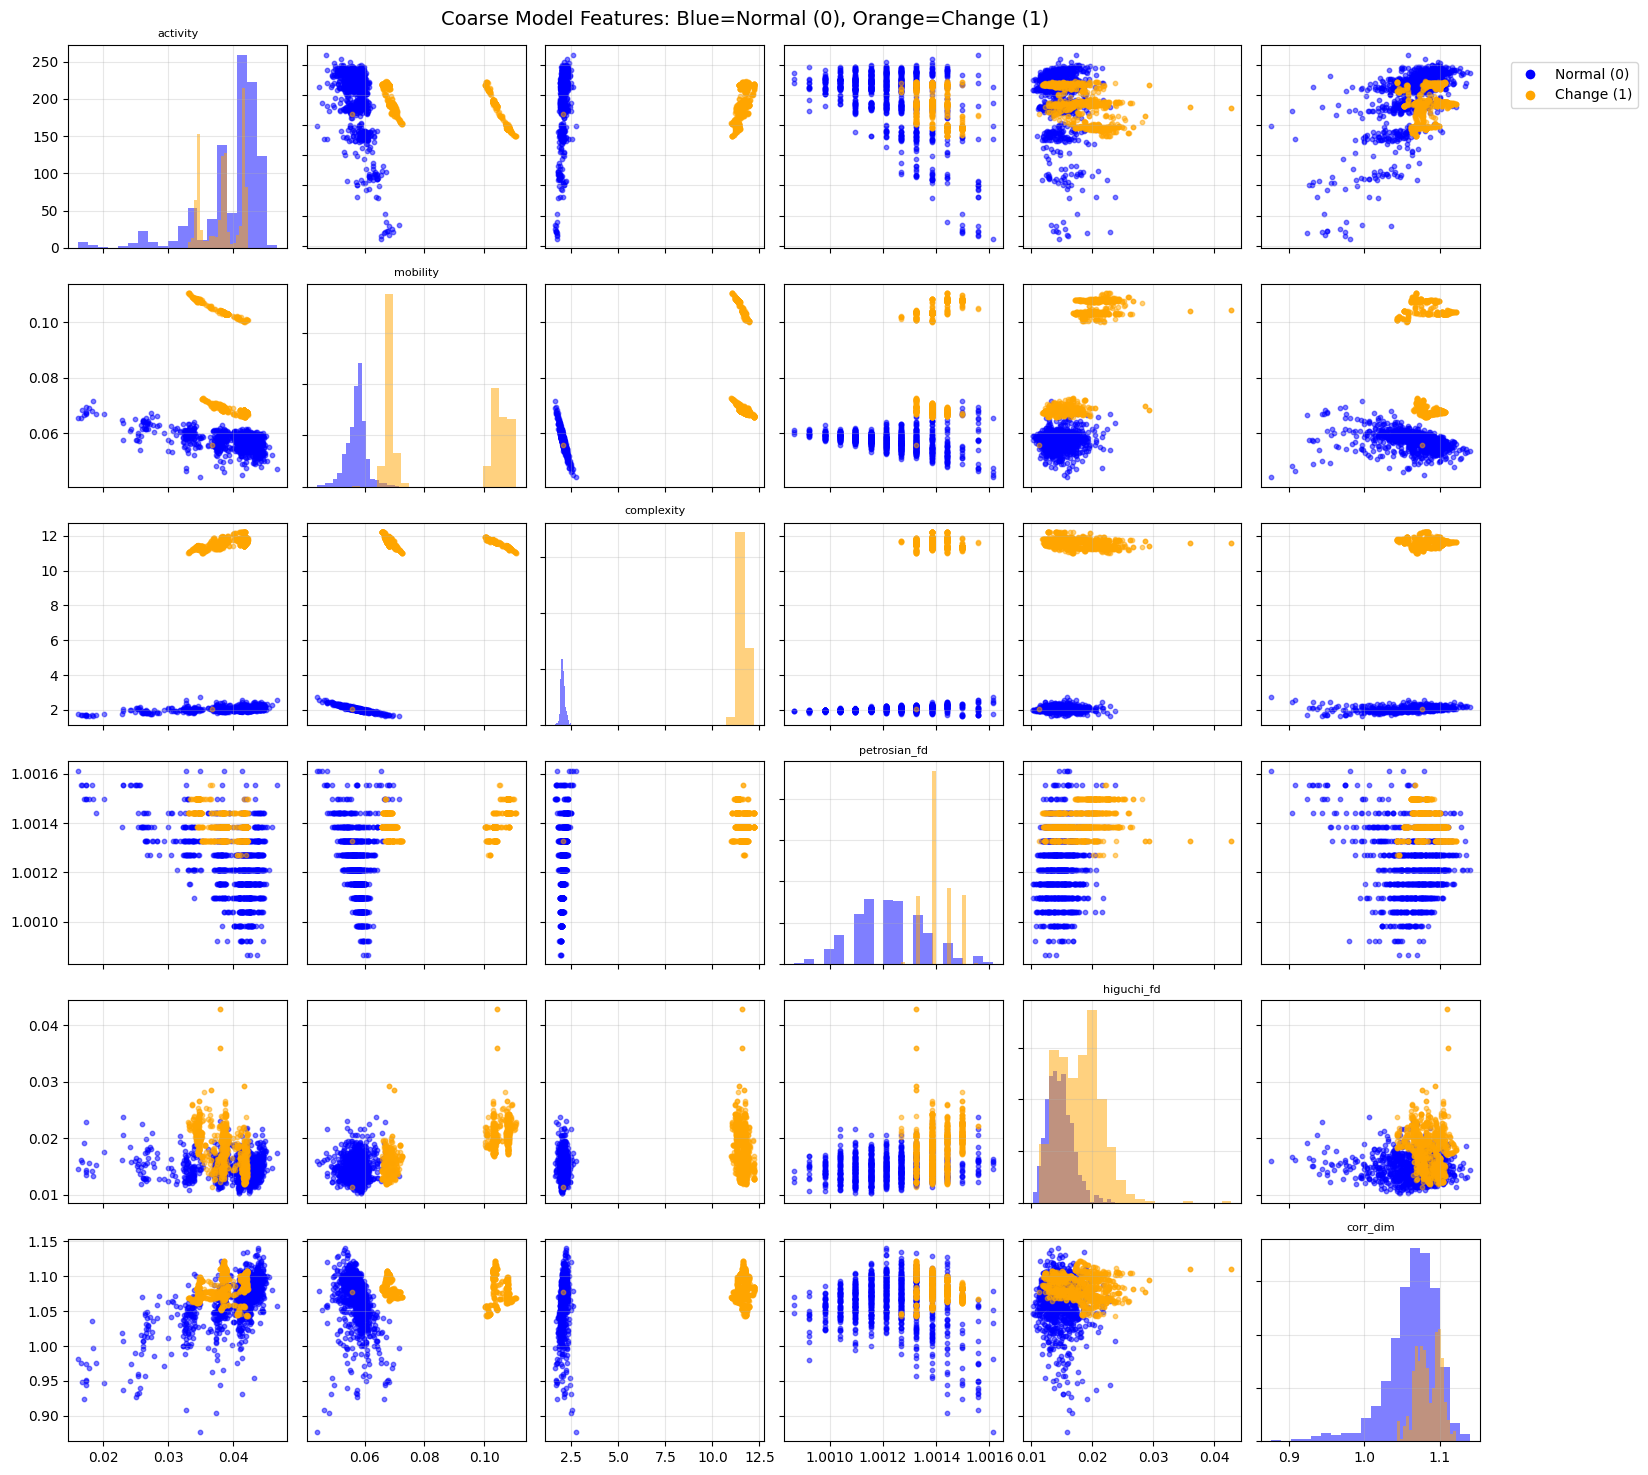

In [45]:
# CELL 4.5: Visualize coarse model features
print("\n" + "=" * 60)
print("COARSE MODEL FEATURE VISUALIZATION")
print("=" * 60)

# Get feature names
feature_names = list(hjorth_features(data[:coarse_window]).keys()) + \
                list(fractal_dimension(data[:coarse_window]).keys())
n_features = len(feature_names)

# Create scatter plot matrix
fig, axes = plt.subplots(n_features, n_features, figsize=(15, 15))
fig.suptitle('Coarse Model Features: Blue=Normal (0), Orange=Change (1)', fontsize=14)

for i in range(n_features):
    for j in range(n_features):
        ax = axes[i, j]

        if i == j:
            # Diagonal: histogram
            ax.hist(X_coarse[y_coarse==0, i], bins=20, alpha=0.5, color='blue', label='Normal')
            ax.hist(X_coarse[y_coarse==1, i], bins=20, alpha=0.5, color='orange', label='Change')
            ax.set_title(feature_names[i], fontsize=8)
        else:
            # Off-diagonal: scatter plot
            ax.scatter(X_coarse[y_coarse==0, j], X_coarse[y_coarse==0, i],
                      c='blue', alpha=0.5, s=10, label='Normal')
            ax.scatter(X_coarse[y_coarse==1, j], X_coarse[y_coarse==1, i],
                      c='orange', alpha=0.5, s=10, label='Change')

        # Remove tick labels for cleaner look
        if i < n_features - 1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

        # Add grid
        ax.grid(True, alpha=0.3)

# Add legend to the whole figure
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
                      markersize=8, label='Normal (0)'),
           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',
                      markersize=8, label='Change (1)')]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.1, 0.95))

plt.tight_layout()
plt.show()

### feature importances

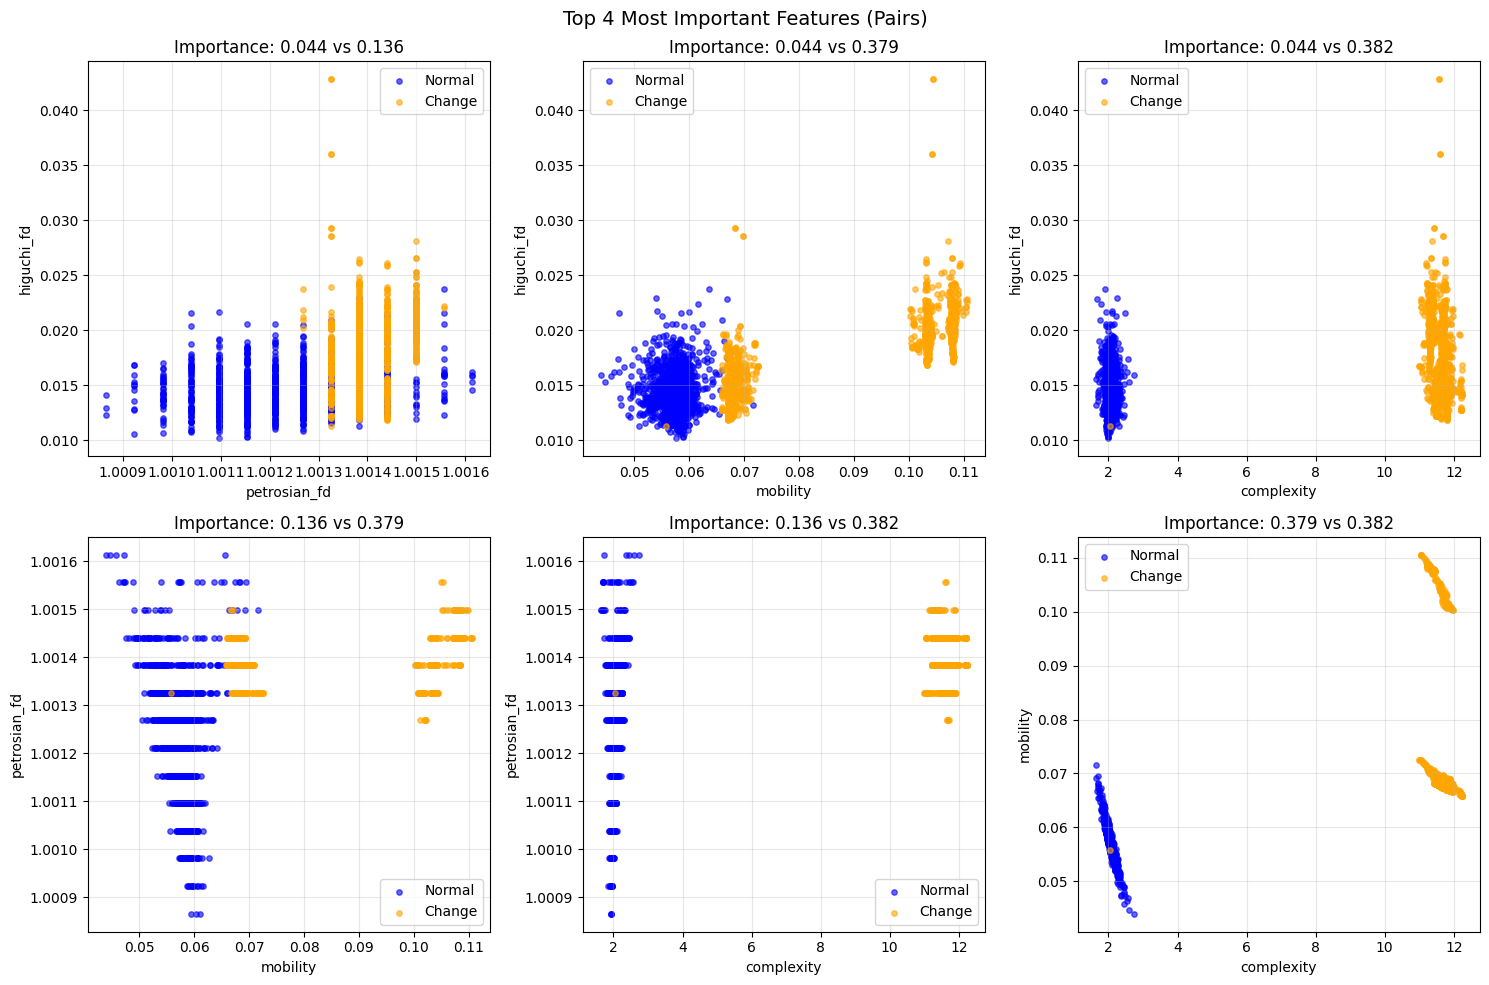


Feature Importance Ranking:
  complexity: 0.3822
  mobility: 0.3790
  petrosian_fd: 0.1360
  higuchi_fd: 0.0435
  corr_dim: 0.0358
  activity: 0.0236


In [46]:
importances = rf_coarse.feature_importances_
top_indices = np.argsort(importances)[-4:]  # Top 4 features

fig2, axes2 = plt.subplots(2, 3, figsize=(15, 10))
axes2 = axes2.flatten()
plot_idx = 0

for i in range(len(top_indices)):
    for j in range(i+1, len(top_indices)):
        if plot_idx < len(axes2):
            ax = axes2[plot_idx]
            ax.scatter(X_coarse[y_coarse==0, top_indices[j]],
                      X_coarse[y_coarse==0, top_indices[i]],
                      c='blue', alpha=0.6, s=15, label='Normal')
            ax.scatter(X_coarse[y_coarse==1, top_indices[j]],
                      X_coarse[y_coarse==1, top_indices[i]],
                      c='orange', alpha=0.6, s=15, label='Change')
            ax.set_xlabel(feature_names[top_indices[j]])
            ax.set_ylabel(feature_names[top_indices[i]])
            ax.set_title(f'Importance: {importances[top_indices[i]]:.3f} vs {importances[top_indices[j]]:.3f}')
            ax.grid(True, alpha=0.3)
            ax.legend()
            plot_idx += 1

plt.suptitle('Top 4 Most Important Features (Pairs)', fontsize=14)
plt.tight_layout()
plt.show()

# Print feature importance ranking
print("\nFeature Importance Ranking:")
for idx in np.argsort(importances)[::-1]:
    print(f"  {feature_names[idx]}: {importances[idx]:.4f}")

## find candidate regions using coarse model

In [41]:
# CELL 5: Use saved windows to find change regions (no rescanning!)
print("=" * 60)
print("EXTRACTING CHANGE REGIONS FROM SAVED WINDOWS")
print("=" * 60)

# Get model predictions on ALL saved coarse windows
print("Getting predictions on saved windows...")
coarse_predictions = rf_coarse.predict_proba(X_coarse)[:, 1]

# Find positive windows (predicted as change)
positive_windows = []
for i, (prob, info) in enumerate(zip(coarse_predictions, coarse_windows_info)):
    if prob > 0.6:  # High confidence change
        center = (info['start'] + info['end']) // 2
        positive_windows.append(center)

print(f"Found {len(positive_windows)} positive windows out of {len(coarse_windows_info)}")

# Group nearby centers into regions
if len(positive_windows) > 0:
    positive_windows.sort()
    merged_regions = []
    current_region = [positive_windows[0] - coarse_window//2,
                      positive_windows[0] + coarse_window//2]

    for center in positive_windows[1:]:
        if center - current_region[1] < 2000:  # Merge if within 2000 points
            current_region[1] = max(current_region[1], center + coarse_window//2)
        else:
            merged_regions.append(current_region)
            current_region = [center - coarse_window//2, center + coarse_window//2]
    merged_regions.append(current_region)

    print(f"Merged into {len(merged_regions)} regions:")
    for i, (start, end) in enumerate(merged_regions):
        print(f"  Region {i+1}: [{start}, {end}], length={end-start}")
else:
    print("No positive windows found, using all windows with prob > 0.3")
    positive_windows = [i for i, prob in enumerate(coarse_predictions) if prob > 0.3]
    print(f"Found {len(positive_windows)} windows with lower threshold")

EXTRACTING CHANGE REGIONS FROM SAVED WINDOWS
Getting predictions on saved windows...
Found 990 positive windows out of 1980
Merged into 99 regions:
  Region 1: [191044, 192801], length=1757
  Region 2: [383072, 384985], length=1913
  Region 3: [575035, 576946], length=1911
  Region 4: [767072, 768751], length=1679
  Region 5: [959178, 960997], length=1819
  Region 6: [1151029, 1152988], length=1959
  Region 7: [1343120, 1344828], length=1708
  Region 8: [1535123, 1536943], length=1820
  Region 9: [1727017, 1728983], length=1966
  Region 10: [1919023, 1920783], length=1760
  Region 11: [2111201, 2112994], length=1793
  Region 12: [2303034, 2304854], length=1820
  Region 13: [2495063, 2497009], length=1946
  Region 14: [2687104, 2689012], length=1908
  Region 15: [2879166, 2881012], length=1846
  Region 16: [3071044, 3072753], length=1709
  Region 17: [3263034, 3265004], length=1970
  Region 18: [3455075, 3456856], length=1781
  Region 19: [3647033, 3648992], length=1959
  Region 20: [38

## fine model data + model

In [42]:
# CELL 6: Prepare fine model data (50-length windows within candidate regions)
print("\n" + "=" * 60)
print("FINE MODEL: 50-length windows within candidate regions")
print("=" * 60)

fine_window = 50
X_fine, y_fine = [], []

if len(merged_regions) > 0:
    for region_start, region_end in merged_regions:
        # Get coarse model predictions on fine windows within this region
        # to use as pseudo-labels (no ground truth leakage!)
        region_probs = []
        region_features = []

        # Sample fine windows within region
        for i in range(region_start, region_end - fine_window, 10):
            window = data[i:i + fine_window]
            features = extract_features(window)
            region_features.append(features)

            # Use coarse model probability as pseudo-label
            prob = rf_coarse.predict_proba([features])[0, 1]
            region_probs.append(prob)

        if len(region_probs) == 0:
            continue

        region_probs = np.array(region_probs)

        # Top 30% highest probabilities = fine change class
        # Bottom 30% = fine normal class (clear separation)
        if len(region_probs) > 10:
            high_threshold = np.percentile(region_probs, 70)
            low_threshold = np.percentile(region_probs, 30)

            for features, prob in zip(region_features, region_probs):
                if prob >= high_threshold:
                    X_fine.append(features)
                    y_fine.append(1)  # High confidence = change
                elif prob <= low_threshold:
                    X_fine.append(features)
                    y_fine.append(0)  # Low confidence = normal

X_fine = np.array(X_fine)
y_fine = np.array(y_fine)

print(f"Total samples: {len(X_fine)}")
if len(y_fine) > 0:
    print(f"Change samples: {np.sum(y_fine)} ({100*np.sum(y_fine)/len(y_fine):.1f}%)")
    print(f"Normal samples: {len(y_fine) - np.sum(y_fine)}")
else:
    print("No samples collected!")


FINE MODEL: 50-length windows within candidate regions
Total samples: 11058
Change samples: 5394 (48.8%)
Normal samples: 5664


In [43]:
if len(np.unique(y_fine)) >= 2 and len(y_fine) > 20:
    Xf_train, Xf_test, yf_train, yf_test = train_test_split(
        X_fine, y_fine, test_size=0.3, random_state=42, stratify=y_fine
    )

    rf_fine = RandomForestClassifier(
        n_estimators=100, max_depth=8, class_weight='balanced', random_state=42
    )
    rf_fine.fit(Xf_train, yf_train)

    yf_pred = rf_fine.predict(Xf_test)
    print("\nFine Model Classification Report:")
    print(classification_report(yf_test, yf_pred, target_names=['Normal', 'Change']))

    # Show top features for fine model
    feature_names = list(hjorth_features(data[:fine_window]).keys()) + \
                    list(fractal_dimension(data[:fine_window]).keys())
    importances = rf_fine.feature_importances_
    print("\nTop Fine Model Features:")
    top_idx = np.argsort(importances)[-3:][::-1]
    for idx in top_idx:
        print(f"  {feature_names[idx]}: {importances[idx]:.3f}")
else:
    print("Cannot train fine model: need both classes")
    rf_fine = None


Fine Model Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1700
      Change       1.00      1.00      1.00      1618

    accuracy                           1.00      3318
   macro avg       1.00      1.00      1.00      3318
weighted avg       1.00      1.00      1.00      3318


Top Fine Model Features:
  corr_dim: 0.411
  higuchi_fd: 0.258
  mobility: 0.152


## final prediction - combine both models

In [44]:
# CELL 7: Final prediction - combine both models
print("\n" + "=" * 60)
print("FINAL PREDICTION ON FULL DATASET")
print("=" * 60)

# Use coarse model to find candidate regions, then fine model to pinpoint
stride = 500  # Coarse stride for speed
final_predictions = []

for i in range(0, len(data) - fine_window, 10):
    window = data[i:i + fine_window]
    features = extract_features(window)

    # Get both model predictions
    coarse_prob = rf_coarse.predict_proba([features])[0, 1]

    if rf_fine is not None:
        fine_prob = rf_fine.predict_proba([features])[0, 1]
        # Combined: high confidence from both models
        final_prob = (coarse_prob + fine_prob) / 2
    else:
        final_prob = coarse_prob

    if final_prob > 0.7:  # High confidence change
        final_predictions.append((i + fine_window//2, final_prob))

# Group nearby predictions
if len(final_predictions) > 0:
    # Find peaks in predictions
    positions = np.array([p[0] for p in final_predictions])
    probs = np.array([p[1] for p in final_predictions])

    peaks, properties = find_peaks(probs, height=0.7, distance=500)

    if len(peaks) > 0:
        detected_changes = positions[peaks]
        detected_confs = probs[peaks]

        print(f"Detected {len(detected_changes)} change points:")
        for i, (pos, conf) in enumerate(zip(detected_changes, detected_confs)):
            print(f"  Change {i+1}: position {pos}, confidence {conf:.3f}")

        print(f"\nTrue change points: {change_indices}")

        # Match detected to true changes
        for true_cp in change_indices:
            distances = np.abs(detected_changes - true_cp)
            best_match = np.argmin(distances)
            error = distances[best_match]
            print(f"  True: {true_cp}, Closest detected: {detected_changes[best_match]}, Error: {error}")
    else:
        print("No peaks found in predictions")
else:
    print("No final predictions above threshold")


FINAL PREDICTION ON FULL DATASET


KeyboardInterrupt: 

## plot

In [ ]:
# CELL 8: Visualization
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Plot 1: Full data with change points and detected regions
ax1 = axes[0]
ax1.plot(data[:50000], 'b-', linewidth=0.5, alpha=0.7)  # Show first 50k points for clarity
for ci in change_indices:
    if ci < 50000:
        ax1.axvline(x=ci, color='red', linestyle='--', linewidth=2, alpha=0.8)
        ax1.axvspan(ci - 500, ci + 500, alpha=0.2, color='yellow')

# Show merged regions
for region_start, region_end in merged_regions:
    if region_start < 50000:
        ax1.axvspan(region_start, min(region_end, 50000), alpha=0.1, color='green')

ax1.set_title('Full Time Series with Change Points and Detected Regions')
ax1.set_xlabel('Time index')
ax1.set_ylabel('Value')
ax1.legend(['Data', 'True Changes', '±500 Context', 'Detected Regions'], loc='upper right')

# Plot 2: Zoom on first change with model probabilities
ax2 = axes[1]
change_idx = change_indices[0]
start_plot = max(0, change_idx - 1000)
end_plot = min(len(data), change_idx + 1000)

ax2.plot(range(start_plot, end_plot), data[start_plot:end_plot], 'b-', linewidth=1, alpha=0.7)
ax2.axvline(x=change_idx, color='red', linestyle='--', linewidth=2, label='True Change')

# Add probability overlay
prob_positions = []
prob_values = []
for i in range(start_plot, end_plot - fine_window, 20):
    window = data[i:i + fine_window]
    features = extract_features(window)
    prob = rf_coarse.predict_proba([features])[0, 1]
    prob_positions.append(i + fine_window//2)
    prob_values.append(prob)

ax2_twin = ax2.twinx()
ax2_twin.plot(prob_positions, prob_values, 'g-', linewidth=1, alpha=0.5, label='Coarse Prob')
if rf_fine is not None:
    fine_probs = []
    for i in range(start_plot, end_plot - fine_window, 20):
        window = data[i:i + fine_window]
        features = extract_features(window)
        prob = rf_fine.predict_proba([features])[0, 1]
        fine_probs.append(prob)
    ax2_twin.plot(prob_positions, fine_probs, 'orange', linewidth=1, alpha=0.5, label='Fine Prob')

ax2_twin.set_ylabel('Change Probability', color='g')
ax2_twin.legend(loc='upper left')
ax2.set_title(f'Zoom: First Change with Model Probabilities')
ax2.set_xlabel('Time index')
ax2.set_ylabel('Value')

# Plot 3: Feature importance comparison
ax3 = axes[2]
feature_names = list(hjorth_features(data[:100]).keys()) + list(fractal_dimension(data[:100]).keys())

coarse_importance = rf_coarse.feature_importances_
x_pos = np.arange(len(feature_names))
width = 0.35

ax3.bar(x_pos - width/2, coarse_importance, width, label='Coarse Model', alpha=0.7)
if rf_fine is not None:
    fine_importance = rf_fine.feature_importances_
    ax3.bar(x_pos + width/2, fine_importance, width, label='Fine Model', alpha=0.7)

ax3.set_xticks(x_pos)
ax3.set_xticklabels(feature_names, rotation=45, ha='right')
ax3.set_title('Feature Importance Comparison')
ax3.set_ylabel('Importance')
ax3.legend()

plt.tight_layout()
plt.show()

# Print final comparison
print("\n" + "=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
print(f"Coarse model: {len(X_coarse)} samples, {len(merged_regions)} regions detected")
print(f"Fine model: {len(X_fine) if len(X_fine) > 0 else 0} samples")
print(f"Features used: {feature_names}")
print(f"True changes: {len(change_indices)}, Detected: {len(detected_changes) if len(final_predictions) > 0 else 0}")

# test model

In [55]:
# CELL 9: Generate NEW test data with different parameters
print("=" * 60)
print("GENERATING NEW TEST DATA (Different Parameters)")
print("=" * 60)

# New parameters for testing
r1_test = 30.0  # Different from training (was 28.0)
r2_test = 32.0  # Different from training (was 29.4)

dt = 0.01
points_per_segment = 192000
skip = 1000

test_segments = []
test_change_indices = []
current_idx = 0

print(f"Using r1={r1_test}, r2={r2_test}")
for i in range(5):
    r = r1_test if i % 2 == 0 else r2_test
    lorenz = Lorentz(r=r)
    x, _, _ = lorenz.generate(dt, points_per_segment + skip)
    x = x[skip:]
    x_norm = (x - x.min()) / (x.max() - x.min())
    test_segments.append(x_norm)
    if i > 0:
        test_change_indices.append(current_idx)
    current_idx += len(x_norm)

test_data = np.concatenate(test_segments)
print(f"Total test points: {len(test_data)}")
print(f"True change indices (hidden): {test_change_indices}")

GENERATING NEW TEST DATA (Different Parameters)
Using r1=30.0, r2=32.0
Total test points: 960005
True change indices (hidden): [192001, 384002, 576003, 768004]


## coarse

In [56]:
# CELL 10: STEP 1 - Coarse detection on new data
print("\n" + "=" * 60)
print("STEP 1: COARSE DETECTION ON NEW DATA")
print("=" * 60)

coarse_window = 1001
stride = 500  # Efficient scanning

# Scan with coarse model (no training, just prediction)
coarse_predictions = []
scan_positions = []

print("Scanning new data with coarse model...")
for i in range(0, len(test_data) - coarse_window, stride):
    window = test_data[i:i + coarse_window]
    features = extract_features(window)
    prob = rf_coarse.predict_proba([features])[0, 1]

    coarse_predictions.append(prob)
    scan_positions.append(i + coarse_window // 2)

coarse_predictions = np.array(coarse_predictions)
scan_positions = np.array(scan_positions)

# Find high confidence change regions
high_conf_mask = coarse_predictions > 0.6
high_conf_positions = scan_positions[high_conf_mask]
high_conf_probs = coarse_predictions[high_conf_mask]

print(f"Found {len(high_conf_positions)} high-confidence positions out of {len(scan_positions)}")

# Group into regions
if len(high_conf_positions) > 0:
    # Sort by position
    sort_idx = np.argsort(high_conf_positions)
    high_conf_positions = high_conf_positions[sort_idx]

    merged_regions = []
    current_region = [high_conf_positions[0] - coarse_window//2,
                      high_conf_positions[0] + coarse_window//2]

    for pos in high_conf_positions[1:]:
        if pos - current_region[1] < 2000:  # Merge if close
            current_region[1] = max(current_region[1], pos + coarse_window//2)
        else:
            merged_regions.append(current_region)
            current_region = [pos - coarse_window//2, pos + coarse_window//2]
    merged_regions.append(current_region)

    print(f"Grouped into {len(merged_regions)} regions:")
    for i, (start, end) in enumerate(merged_regions):
        print(f"  Region {i+1}: [{start}, {end}], length={end-start}")
else:
    print("No high-confidence regions found! Lowering threshold...")
    high_conf_mask = coarse_predictions > 0.4
    high_conf_positions = scan_positions[high_conf_mask]
    print(f"Found {len(high_conf_positions)} positions with threshold 0.4")
    merged_regions = []


STEP 1: COARSE DETECTION ON NEW DATA
Scanning new data with coarse model...
Found 7 high-confidence positions out of 1919
Grouped into 4 regions:
  Region 1: [191500, 192500], length=1000
  Region 2: [383500, 385000], length=1500
  Region 3: [575500, 577000], length=1500
  Region 4: [767500, 769000], length=1500


## fine

In [57]:
# CELL 11: STEP 2 - Fine detection within regions
print("\n" + "=" * 60)
print("STEP 2: FINE DETECTION WITHIN REGIONS")
print("=" * 60)

fine_window = 50
detected_changes = []

if len(merged_regions) > 0 and rf_fine is not None:
    for region_start, region_end in merged_regions:
        region_probs = []
        region_positions = []

        # Dense scanning within each region
        for i in range(region_start, region_end - fine_window, 5):
            window = test_data[i:i + fine_window]
            features = extract_features(window)
            prob = rf_fine.predict_proba([features])[0, 1]
            region_probs.append(prob)
            region_positions.append(i + fine_window//2)

        if len(region_probs) == 0:
            continue

        region_probs = np.array(region_probs)
        region_positions = np.array(region_positions)

        # Find peaks in probability
        peaks, properties = find_peaks(region_probs, height=0.7, distance=50)

        if len(peaks) > 0:
            # Take the best peak in this region
            best_peak = peaks[np.argmax(region_probs[peaks])]
            detected_changes.append({
                'position': region_positions[best_peak],
                'confidence': region_probs[best_peak],
                'region': (region_start, region_end)
            })
        else:
            # If no clear peak, take the maximum probability point
            max_idx = np.argmax(region_probs)
            if region_probs[max_idx] > 0.5:
                detected_changes.append({
                    'position': region_positions[max_idx],
                    'confidence': region_probs[max_idx],
                    'region': (region_start, region_end)
                })

if len(detected_changes) > 0:
    print(f"\nDetected {len(detected_changes)} change points:")
    for i, d in enumerate(detected_changes):
        print(f"  Change {i+1}: position {d['position']}, confidence {d['confidence']:.3f}")

    # Compare with true changes (if we peek for evaluation)
    print(f"\nTrue change points (for evaluation): {test_change_indices}")
    print("\nDetection errors:")
    for true_cp in test_change_indices:
        if len(detected_changes) > 0:
            positions = np.array([d['position'] for d in detected_changes])
            distances = np.abs(positions - true_cp)
            best_match = np.argmin(distances)
            error = distances[best_match]
            print(f"  True: {true_cp}, Detected: {positions[best_match]}, Error: {error:.0f} points")
        else:
            print(f"  True: {true_cp}, No detection nearby")

    mean_error = np.mean([min(np.abs(np.array([d['position'] for d in detected_changes]) - tc))
                          for tc in test_change_indices])
    print(f"\nMean absolute error: {mean_error:.0f} points")
else:
    print("No changes detected!")


STEP 2: FINE DETECTION WITHIN REGIONS

Detected 4 change points:
  Change 1: position 191560, confidence 1.000
  Change 2: position 383650, confidence 1.000
  Change 3: position 575565, confidence 1.000
  Change 4: position 767655, confidence 1.000

True change points (for evaluation): [192001, 384002, 576003, 768004]

Detection errors:
  True: 192001, Detected: 191560, Error: 441 points
  True: 384002, Detected: 383650, Error: 352 points
  True: 576003, Detected: 575565, Error: 438 points
  True: 768004, Detected: 767655, Error: 349 points

Mean absolute error: 395 points


## plot

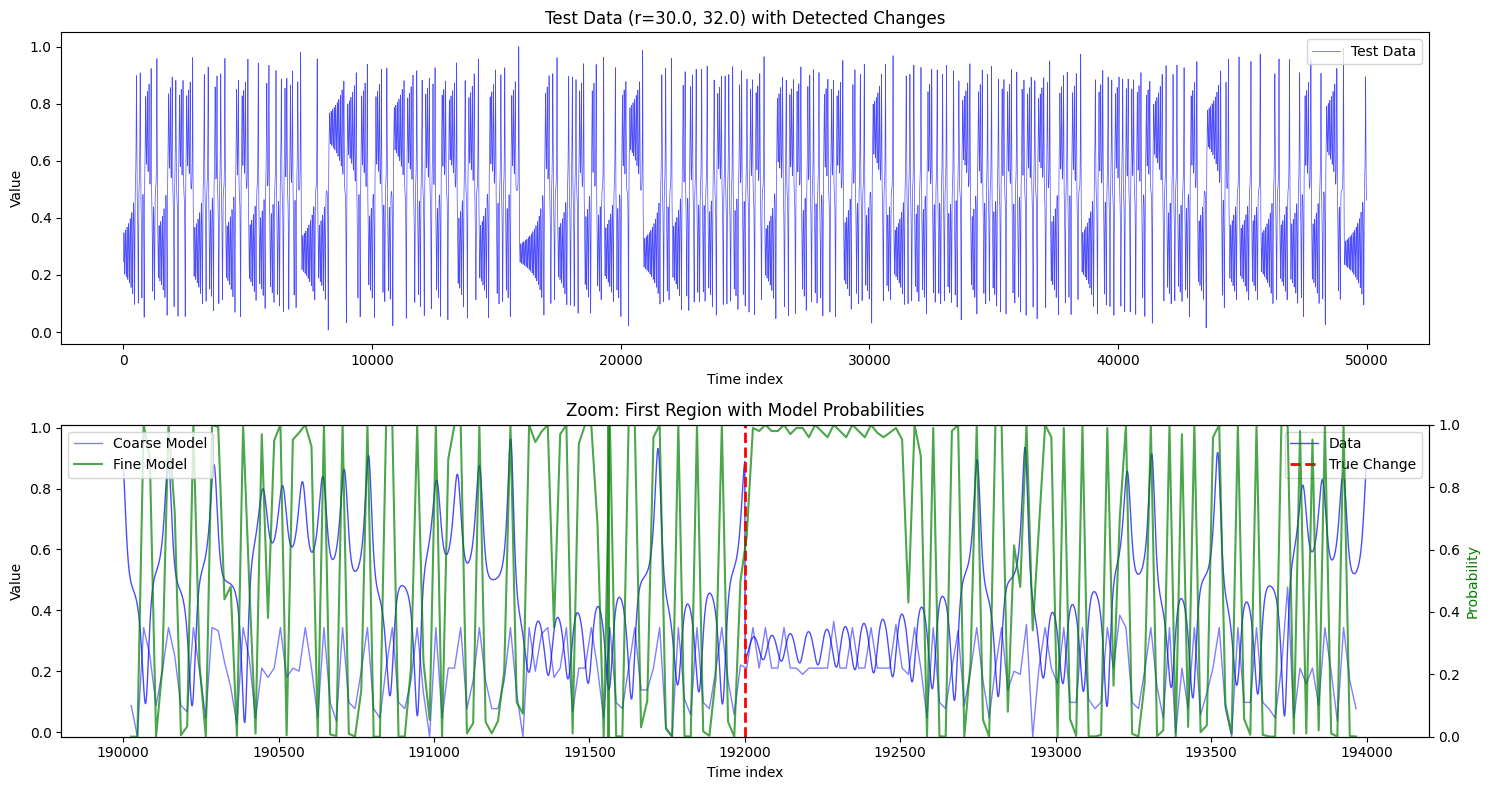


TEST RESULTS SUMMARY
Training parameters: r=[28.0, 29.4]
Test parameters: r=[30.0, 32.0]
Coarse regions found: 4
Changes detected: 4
True changes: 4
Mean error: 395 points
Max error: 441 points
Min error: 349 points


In [58]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Plot 1: Full test data with detection results
ax1 = axes[0]
plot_limit = min(50000, len(test_data))
ax1.plot(test_data[:plot_limit], 'b-', linewidth=0.5, alpha=0.7, label='Test Data')
for ci in test_change_indices:
    if ci < plot_limit:
        ax1.axvline(x=ci, color='red', linestyle='--', linewidth=2, alpha=0.8, label='True Change')
for d in detected_changes:
    if d['position'] < plot_limit:
        ax1.axvline(x=d['position'], color='green', linewidth=2, alpha=0.8, label='Detected')

ax1.set_title(f'Test Data (r={r1_test}, {r2_test}) with Detected Changes')
ax1.set_xlabel('Time index')
ax1.set_ylabel('Value')

# Clean up legend duplicates
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper right')

# Plot 2: Zoom on first detected region with probabilities
ax2 = axes[1]
if len(test_change_indices) > 0:
    tc = test_change_indices[0]
    start_plot = max(0, tc - 2000)
    end_plot = min(len(test_data), tc + 2000)

    ax2.plot(range(start_plot, end_plot), test_data[start_plot:end_plot],
            'b-', linewidth=1, alpha=0.7)
    ax2.axvline(x=tc, color='red', linestyle='--', linewidth=2, label='True')

    # Overlay coarse model probabilities
    coarse_probs_zoom = []
    fine_probs_zoom = []
    prob_positions_zoom = []

    for i in range(start_plot, end_plot - fine_window, 20):
        window = test_data[i:i + fine_window]
        features = extract_features(window)

        # Both model probabilities
        if rf_coarse is not None:
            c_prob = rf_coarse.predict_proba([features])[0, 1]
        else:
            c_prob = 0

        if rf_fine is not None:
            f_prob = rf_fine.predict_proba([features])[0, 1]
        else:
            f_prob = 0

        coarse_probs_zoom.append(c_prob)
        fine_probs_zoom.append(f_prob)
        prob_positions_zoom.append(i + fine_window//2)

    ax2_twin = ax2.twinx()
    ax2_twin.plot(prob_positions_zoom, coarse_probs_zoom, 'blue',
                  linewidth=1, alpha=0.5, label='Coarse Model')
    ax2_twin.plot(prob_positions_zoom, fine_probs_zoom, 'green',
                  linewidth=1.5, alpha=0.7, label='Fine Model')

    # Mark detected change
    for d in detected_changes:
        if start_plot <= d['position'] <= end_plot:
            ax2.axvline(x=d['position'], color='green', linewidth=2, alpha=0.8)

    ax2_twin.set_ylabel('Probability', color='green')
    ax2_twin.set_ylim([0, 1])
    ax2_twin.legend(loc='upper left')

    ax2.set_title(f'Zoom: First Region with Model Probabilities')
    ax2.set_xlabel('Time index')
    ax2.set_ylabel('Value')
    ax2.legend(['Data', 'True Change'], loc='upper right')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 60)
print("TEST RESULTS SUMMARY")
print("=" * 60)
print(f"Training parameters: r=[28.0, 29.4]")
print(f"Test parameters: r=[{r1_test}, {r2_test}]")
print(f"Coarse regions found: {len(merged_regions)}")
print(f"Changes detected: {len(detected_changes)}")
print(f"True changes: {len(test_change_indices)}")
if len(detected_changes) > 0 and len(test_change_indices) > 0:
    errors = [min(np.abs(np.array([d['position'] for d in detected_changes]) - tc))
              for tc in test_change_indices]
    print(f"Mean error: {np.mean(errors):.0f} points")
    print(f"Max error: {np.max(errors):.0f} points")
    print(f"Min error: {np.min(errors):.0f} points")

DETAILED MODEL BEHAVIOR VISUALIZATION


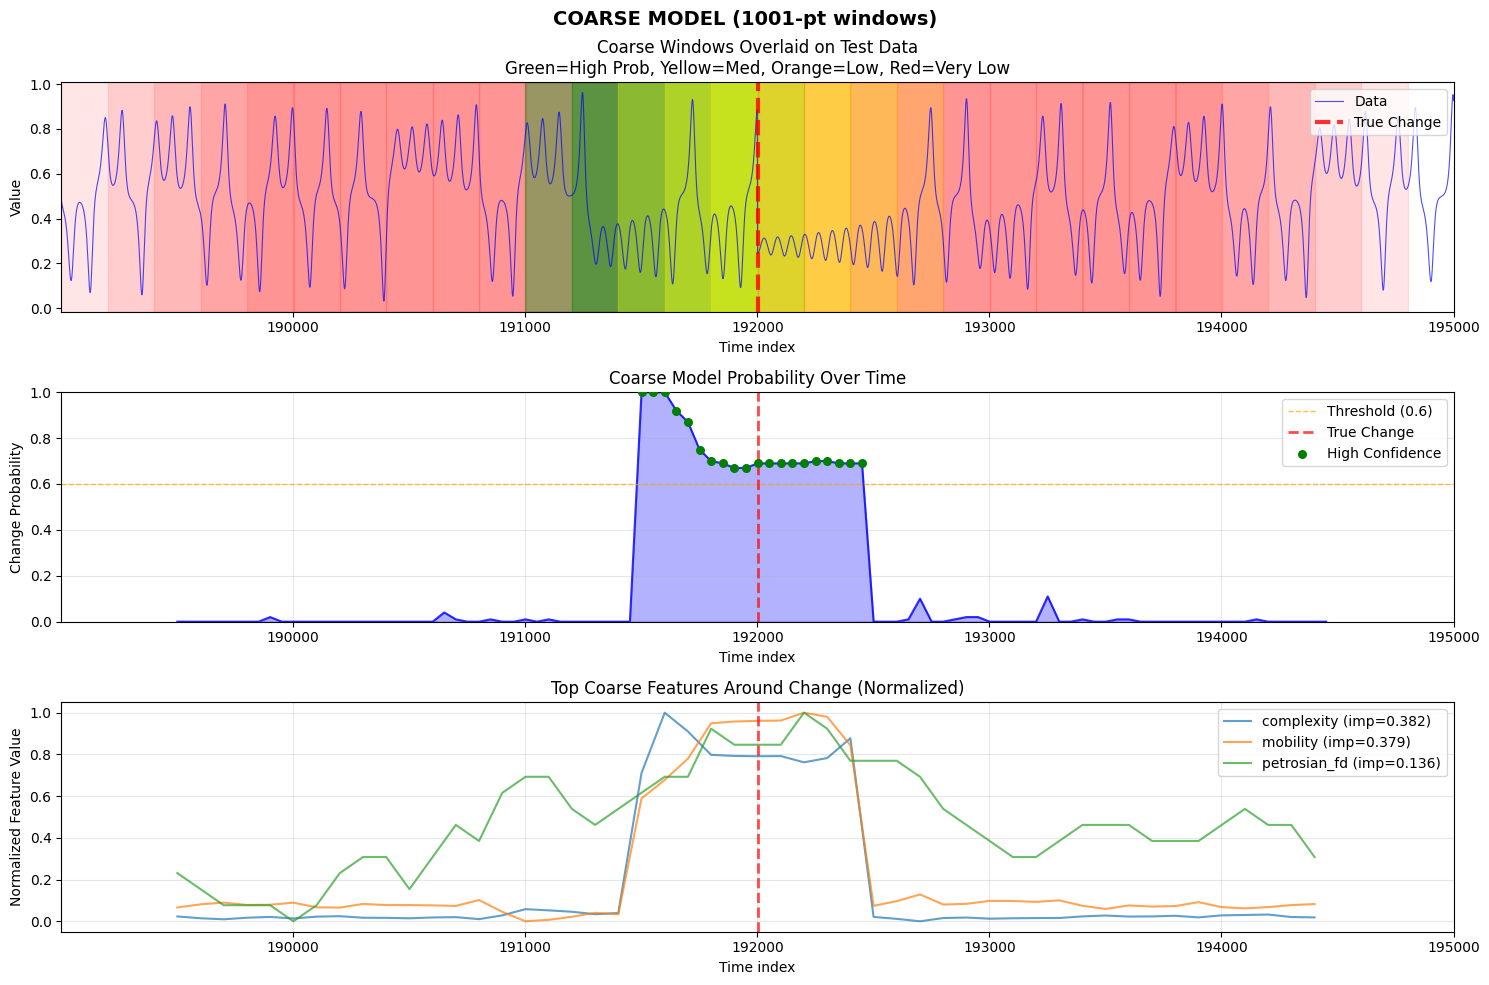

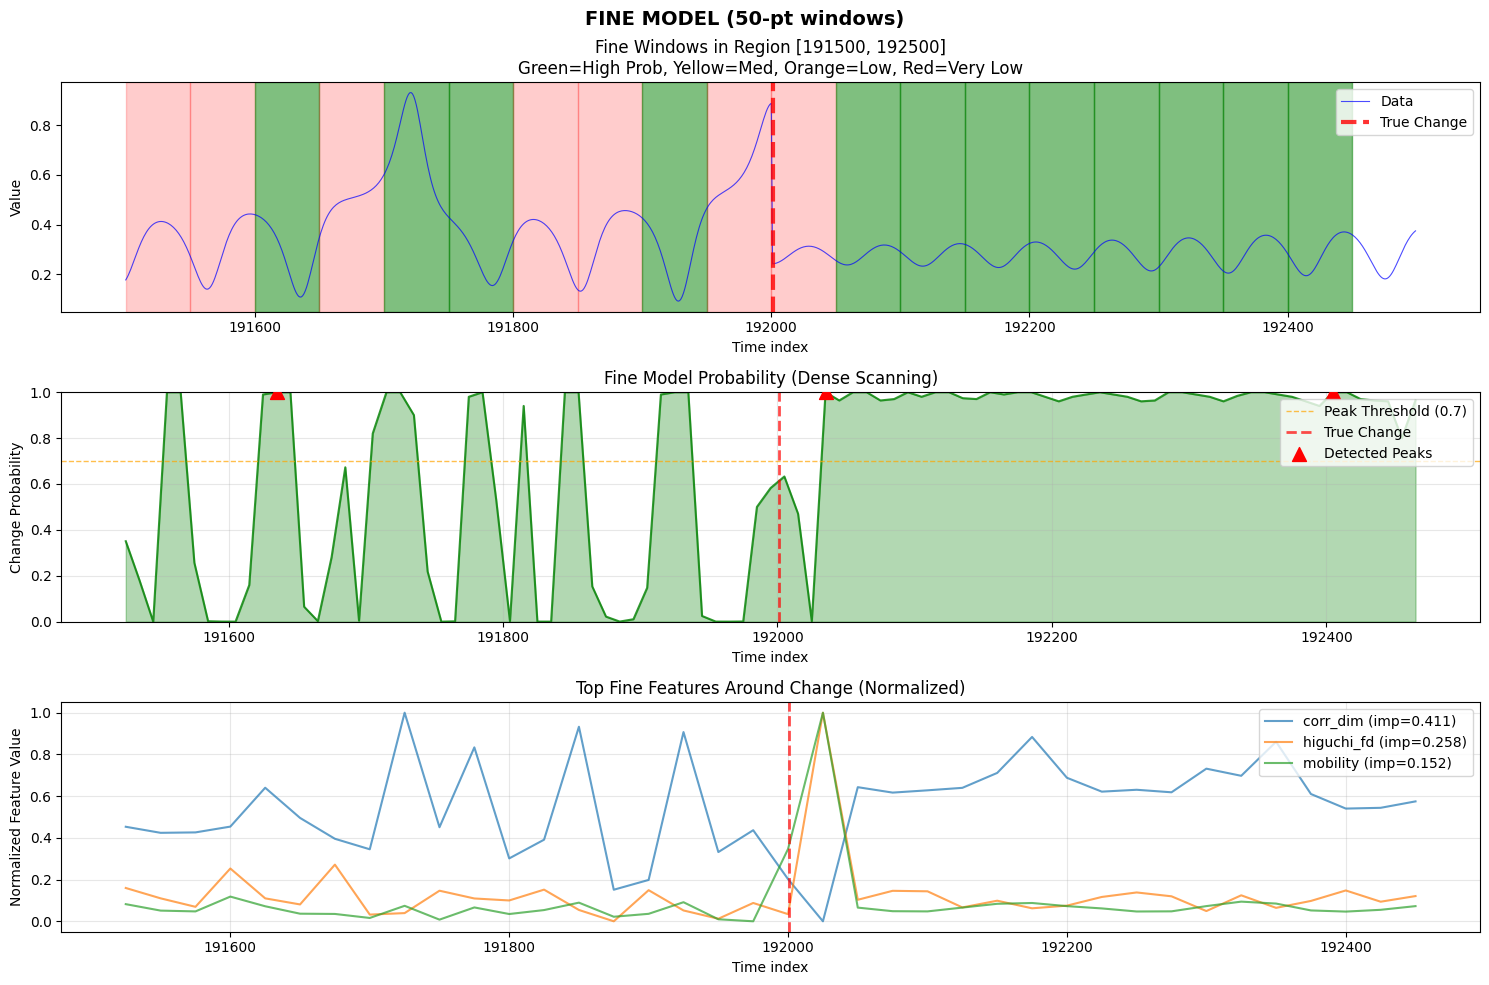

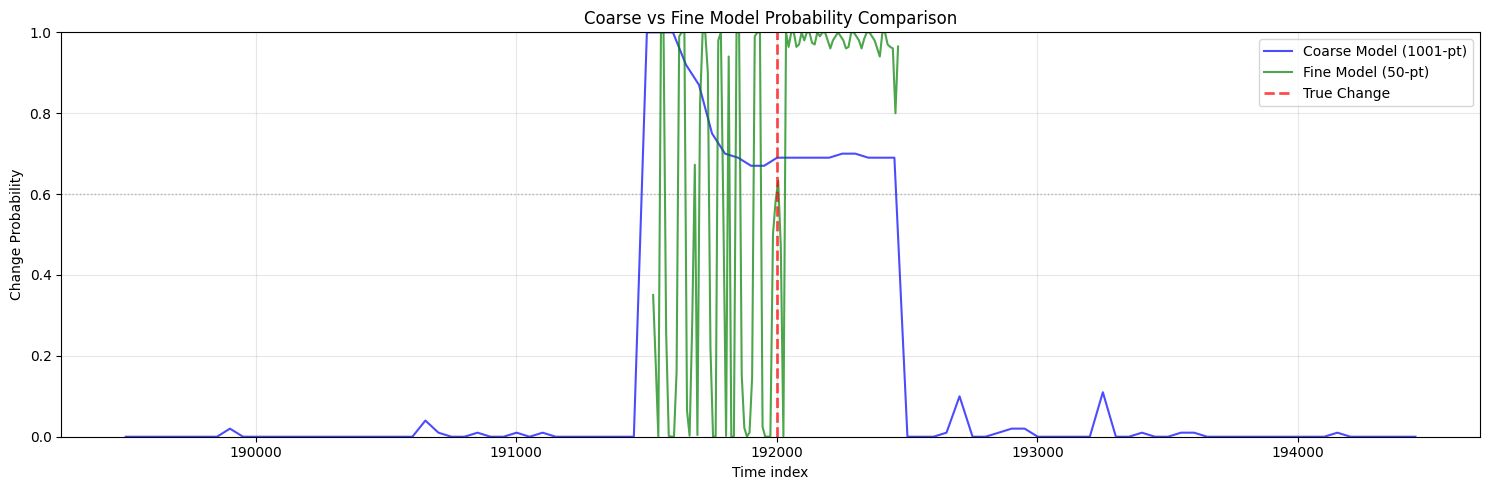


Coarse model finds the approximate region (wider, smoother)
Fine model pinpoints exact location (sharper, more precise)
True change at position 192001


In [59]:
# CELL 12: Detailed visualization of coarse and fine model behavior
print("=" * 60)
print("DETAILED MODEL BEHAVIOR VISUALIZATION")
print("=" * 60)

# Pick the first test change for detailed analysis
if len(test_change_indices) > 0:
    tc = test_change_indices[0]

    # Define windows for visualization
    zoom_start = max(0, tc - 3000)
    zoom_end = min(len(test_data), tc + 3000)

    # ============ COARSE MODEL PLOT ============
    fig_coarse, axes_coarse = plt.subplots(3, 1, figsize=(15, 10))
    fig_coarse.suptitle('COARSE MODEL (1001-pt windows)', fontsize=14, fontweight='bold')

    # Subplot 1: Test data with coarse windows highlighted
    ax = axes_coarse[0]
    ax.plot(range(zoom_start, zoom_end), test_data[zoom_start:zoom_end],
            'b-', linewidth=0.8, alpha=0.7, label='Test Data')
    ax.axvline(x=tc, color='red', linestyle='--', linewidth=3, alpha=0.8, label='True Change')

    # Show some coarse windows as colored spans
    stride_coarse = 200
    window_colors = []
    for i in range(zoom_start, zoom_end - coarse_window, stride_coarse):
        window = test_data[i:i + coarse_window]
        features = extract_features(window)
        prob = rf_coarse.predict_proba([features])[0, 1]

        # Color based on probability
        if prob > 0.8:
            color = 'green'
            alpha = 0.4
        elif prob > 0.6:
            color = 'yellow'
            alpha = 0.3
        elif prob > 0.4:
            color = 'orange'
            alpha = 0.2
        else:
            color = 'red'
            alpha = 0.1

        ax.axvspan(i, i + coarse_window, alpha=alpha, color=color)
        window_colors.append((i + coarse_window//2, prob))

    ax.set_title('Coarse Windows Overlaid on Test Data\nGreen=High Prob, Yellow=Med, Orange=Low, Red=Very Low')
    ax.set_xlabel('Time index')
    ax.set_ylabel('Value')
    ax.legend(['Data', 'True Change'], loc='upper right')
    ax.set_xlim([zoom_start, zoom_end])

    # Subplot 2: Coarse model probabilities
    ax = axes_coarse[1]
    coarse_probs_detail = []
    coarse_positions_detail = []

    for i in range(zoom_start, zoom_end - coarse_window, 50):
        window = test_data[i:i + coarse_window]
        features = extract_features(window)
        prob = rf_coarse.predict_proba([features])[0, 1]
        coarse_probs_detail.append(prob)
        coarse_positions_detail.append(i + coarse_window//2)

    ax.plot(coarse_positions_detail, coarse_probs_detail, 'b-', linewidth=1.5, alpha=0.8)
    ax.fill_between(coarse_positions_detail, 0, coarse_probs_detail, alpha=0.3, color='blue')
    ax.axhline(y=0.6, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Threshold (0.6)')
    ax.axvline(x=tc, color='red', linestyle='--', linewidth=2, alpha=0.7, label='True Change')

    # Mark high confidence windows
    high_conf = np.array(coarse_probs_detail) > 0.6
    if np.any(high_conf):
        ax.scatter(np.array(coarse_positions_detail)[high_conf],
                  np.array(coarse_probs_detail)[high_conf],
                  color='green', s=30, zorder=5, label='High Confidence')

    ax.set_title('Coarse Model Probability Over Time')
    ax.set_xlabel('Time index')
    ax.set_ylabel('Change Probability')
    ax.set_ylim([0, 1])
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([zoom_start, zoom_end])

    # Subplot 3: Feature values for coarse windows
    ax = axes_coarse[2]
    feature_names = list(hjorth_features(test_data[:coarse_window]).keys()) + \
                    list(fractal_dimension(test_data[:coarse_window]).keys())

    # Extract features for windows around the change
    feature_matrix = []
    feature_positions = []
    for i in range(zoom_start, zoom_end - coarse_window, 100):
        window = test_data[i:i + coarse_window]
        features = extract_features(window)
        feature_matrix.append(features)
        feature_positions.append(i + coarse_window//2)

    feature_matrix = np.array(feature_matrix)

    # Plot top 3 features
    top_features_idx = np.argsort(rf_coarse.feature_importances_)[-3:][::-1]

    for idx in top_features_idx:
        # Normalize for visualization
        feat_values = feature_matrix[:, idx]
        feat_norm = (feat_values - feat_values.min()) / (feat_values.max() - feat_values.min() + 1e-10)
        ax.plot(feature_positions, feat_norm, linewidth=1.5, alpha=0.7,
               label=f'{feature_names[idx]} (imp={rf_coarse.feature_importances_[idx]:.3f})')

    ax.axvline(x=tc, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.set_title('Top Coarse Features Around Change (Normalized)')
    ax.set_xlabel('Time index')
    ax.set_ylabel('Normalized Feature Value')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([zoom_start, zoom_end])

    plt.tight_layout()
    plt.show()

    # ============ FINE MODEL PLOT ============
    if rf_fine is not None:
        fig_fine, axes_fine = plt.subplots(3, 1, figsize=(15, 10))
        fig_fine.suptitle('FINE MODEL (50-pt windows)', fontsize=14, fontweight='bold')

        # Find the region that contains this change
        region_found = False
        for region_start, region_end in merged_regions:
            if region_start <= tc <= region_end:
                fine_zoom_start = max(zoom_start, region_start)
                fine_zoom_end = min(zoom_end, region_end)
                region_found = True
                break

        if not region_found:
            fine_zoom_start = zoom_start
            fine_zoom_end = zoom_end

        # Subplot 1: Test data with fine windows highlighted
        ax = axes_fine[0]
        ax.plot(range(fine_zoom_start, fine_zoom_end),
                test_data[fine_zoom_start:fine_zoom_end],
                'b-', linewidth=0.8, alpha=0.7, label='Test Data')
        ax.axvline(x=tc, color='red', linestyle='--', linewidth=3, alpha=0.8, label='True Change')

        # Show fine windows as colored spans
        stride_fine = 50
        for i in range(fine_zoom_start, fine_zoom_end - fine_window, stride_fine):
            window = test_data[i:i + fine_window]
            features = extract_features(window)
            prob = rf_fine.predict_proba([features])[0, 1]

            if prob > 0.8:
                color = 'green'
                alpha = 0.5
            elif prob > 0.6:
                color = 'yellow'
                alpha = 0.4
            elif prob > 0.4:
                color = 'orange'
                alpha = 0.3
            else:
                color = 'red'
                alpha = 0.2

            ax.axvspan(i, i + fine_window, alpha=alpha, color=color)

        ax.set_title(f'Fine Windows in Region [{fine_zoom_start}, {fine_zoom_end}]\nGreen=High Prob, Yellow=Med, Orange=Low, Red=Very Low')
        ax.set_xlabel('Time index')
        ax.set_ylabel('Value')
        ax.legend(['Data', 'True Change'], loc='upper right')

        # Subplot 2: Fine model probabilities
        ax = axes_fine[1]
        fine_probs_detail = []
        fine_positions_detail = []

        for i in range(fine_zoom_start, fine_zoom_end - fine_window, 10):
            window = test_data[i:i + fine_window]
            features = extract_features(window)
            prob = rf_fine.predict_proba([features])[0, 1]
            fine_probs_detail.append(prob)
            fine_positions_detail.append(i + fine_window//2)

        ax.plot(fine_positions_detail, fine_probs_detail, 'g-', linewidth=1.5, alpha=0.8)
        ax.fill_between(fine_positions_detail, 0, fine_probs_detail, alpha=0.3, color='green')
        ax.axhline(y=0.7, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Peak Threshold (0.7)')
        ax.axvline(x=tc, color='red', linestyle='--', linewidth=2, alpha=0.7, label='True Change')

        # Find and mark peaks
        fine_probs_array = np.array(fine_probs_detail)
        fine_positions_array = np.array(fine_positions_detail)
        peaks, properties = find_peaks(fine_probs_array, height=0.7, distance=30)

        if len(peaks) > 0:
            ax.scatter(fine_positions_array[peaks], fine_probs_array[peaks],
                      color='red', s=100, zorder=5, marker='^', label='Detected Peaks')

        ax.set_title('Fine Model Probability (Dense Scanning)')
        ax.set_xlabel('Time index')
        ax.set_ylabel('Change Probability')
        ax.set_ylim([0, 1])
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

        # Subplot 3: Feature values for fine windows
        ax = axes_fine[2]

        fine_feature_matrix = []
        fine_feature_positions = []
        for i in range(fine_zoom_start, fine_zoom_end - fine_window, 25):
            window = test_data[i:i + fine_window]
            features = extract_features(window)
            fine_feature_matrix.append(features)
            fine_feature_positions.append(i + fine_window//2)

        fine_feature_matrix = np.array(fine_feature_matrix)

        # Plot top 3 fine features
        if rf_fine is not None:
            top_fine_idx = np.argsort(rf_fine.feature_importances_)[-3:][::-1]

            for idx in top_fine_idx:
                feat_values = fine_feature_matrix[:, idx]
                if feat_values.max() - feat_values.min() > 0:
                    feat_norm = (feat_values - feat_values.min()) / (feat_values.max() - feat_values.min())
                else:
                    feat_norm = np.zeros_like(feat_values)
                ax.plot(fine_feature_positions, feat_norm, linewidth=1.5, alpha=0.7,
                       label=f'{feature_names[idx]} (imp={rf_fine.feature_importances_[idx]:.3f})')

        ax.axvline(x=tc, color='red', linestyle='--', linewidth=2, alpha=0.7)
        ax.set_title('Top Fine Features Around Change (Normalized)')
        ax.set_xlabel('Time index')
        ax.set_ylabel('Normalized Feature Value')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ============ COMPARISON PLOT ============
    fig_compare, ax_compare = plt.subplots(1, 1, figsize=(15, 5))

    # Both probabilities on same plot
    ax_compare.plot(coarse_positions_detail, coarse_probs_detail, 'b-',
                   linewidth=1.5, alpha=0.7, label='Coarse Model (1001-pt)')
    if rf_fine is not None:
        ax_compare.plot(fine_positions_detail, fine_probs_detail, 'g-',
                       linewidth=1.5, alpha=0.7, label='Fine Model (50-pt)')

    ax_compare.axvline(x=tc, color='red', linestyle='--', linewidth=2, alpha=0.7, label='True Change')
    ax_compare.axhline(y=0.6, color='gray', linestyle=':', linewidth=1, alpha=0.5)

    ax_compare.set_title('Coarse vs Fine Model Probability Comparison')
    ax_compare.set_xlabel('Time index')
    ax_compare.set_ylabel('Change Probability')
    ax_compare.set_ylim([0, 1])
    ax_compare.legend(loc='upper right')
    ax_compare.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nCoarse model finds the approximate region (wider, smoother)")
    print(f"Fine model pinpoints exact location (sharper, more precise)")
    print(f"True change at position {tc}")